# PRCL-0012 | ABC Tech ITSM - Machine Learning Project
## Client: ABC Tech | Category: IT Service Management (ITSM)

| Detail | Info |
|---|---|
| **Student Name** | Supriya |
| **Project Ref** | PRCL-0012 |
| **Domain** | IT Service Management (ITSM) |
| **Dataset** | 46,606 IT Incident Records (2012-2014) |
| **Database** | MySQL - project_itsm |
| **Tools** | Python, MySQL, Scikit-learn, Streamlit |

### Problem Statement
ABC Tech receives 22,000–25,000 IT incidents annually. Despite mature ITIL processes,
customer satisfaction is rated poor. This project applies Machine Learning to solve 4 key
business problems:
1. Predict High Priority Tickets (Priority 1 & 2)
2. Forecast Incident Volume (Quarterly & Annual)
3. Auto-Tag Tickets with correct Priority and Department
4. Predict RFC Failures and ITSM Asset Misconfigurations

In [1]:
 !pip install mysql-connector-python


In [2]:
 !pip install sqlalchemy

In [3]:
 !pip install pymysql

## Step 1: Import Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database Connection
import mysql.connector
from sqlalchemy import create_engine

# Date & Time
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


## Step 2: Connect to MySQL Database & Load Data

In [2]:
# MySQL Database Connection
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)

# Load data into DataFrame
df = pd.read_sql("SELECT * FROM dataset_list", conn)

# Close connection
conn.close()

print(f"✅ Data Loaded Successfully!")
print(f"📊 Total Records: {df.shape[0]}")
print(f"📋 Total Columns: {df.shape[1]}")

✅ Data Loaded Successfully!
📊 Total Records: 46606
📋 Total Columns: 25


## Step 3: First Look at Data

In [3]:
# First 5 rows
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [4]:
# Shape of dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 46606
Columns: 25


In [5]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

In [6]:
# Basic statistics
df.describe()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,6,6,6,46606,4,1825,1,42,34636,2245,33628,34528,30639,15,50,43060,25,5,233
top,SUB000456,application,Server Based Application,WBS000073,IM0047057,Closed,4,4,4,0.902319509,incident,KM0001106,closed,0,24-03-2014 08:54,,,02-10-2013 15:20,0,Other,1,#MULTIVALUE,,,
freq,3050,32900,18811,13342,1,46597,22556,22588,22717,1,37748,1106,46606,27468,7,44322,1780,21,236,16470,43058,3434,45384,46046,46046


In [7]:
df.isnull().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Incident_ID                   0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Reopen_Time                   0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Related_Interaction           0
No_of_Related_Incidents       0
No_of_Related_Changes         0
Related_Change                0
dtype: int64

## Step 4: Exploratory Data Analysis (EDA)

The goal of EDA is to understand the structure, distribution, and patterns in the ABC Tech ITSM dataset before building machine learning models. We will explore the target variables, key features, missing values, and relationships between variables across all 4 use cases.

### 4.1 Dataset Overview

In [8]:
# Shape of dataset
print(f"Total Records : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

Total Records : 46606
Total Columns : 25


In [9]:
# Column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status', 'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number', 'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time', 'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions', 'Related_Interaction', 'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']


In [10]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
CI_Name                       object
CI_Cat                        object
CI_Subcat                     object
WBS                           object
Incident_ID                   object
Status                        object
Impact                        object
Urgency                       object
Priority                      object
number_cnt                    object
Category                      object
KB_number                     object
Alert_Status                  object
No_of_Reassignments           object
Open_Time                     object
Reopen_Time                   object
Resolved_Time                 object
Close_Time                    object
Handle_Time_hrs               object
Closure_Code                  object
No_of_Related_Interactions    object
Related_Interaction           object
No_of_Related_Incidents       object
No_of_Related_Changes         object
Related_Change                object
dtype: object


In [11]:
# Missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


### 4.2 Target Variable Analysis — Priority Distribution (Use Case 1 & 3)

Priority is the most important target variable in this project. It is derived from Impact and Urgency using the ITIL Priority Matrix. Understanding its distribution helps us assess class imbalance before building classification models.

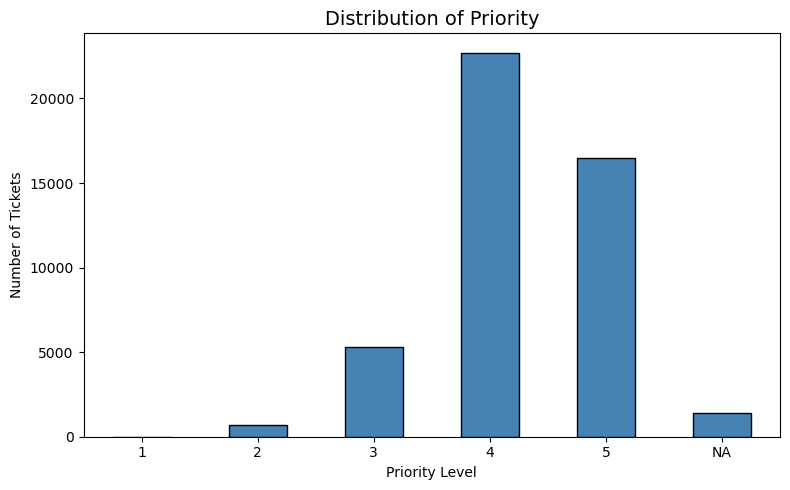

In [12]:
plt.figure(figsize=(8,5))
df['Priority'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Priority', fontsize=14)
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Impact and Urgency Distribution

Impact and Urgency are the two key input variables that determine the Priority of a ticket as per the ITIL Priority Matrix. Analyzing their distributions helps understand how tickets are spread across severity levels.

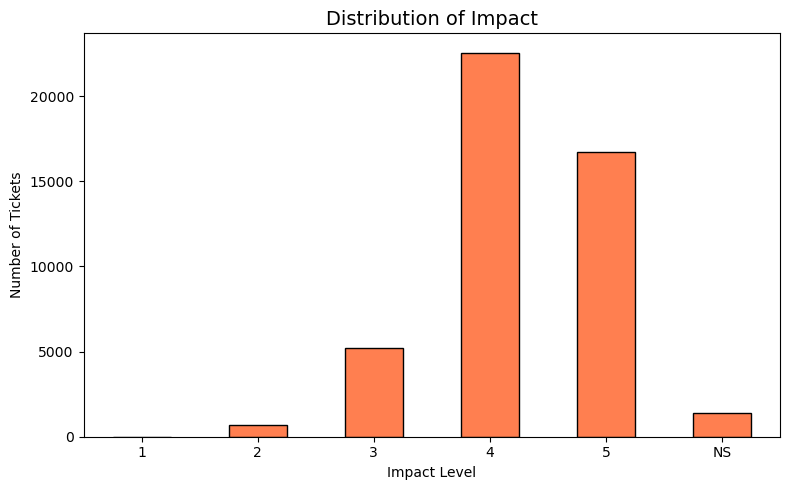

In [13]:
plt.figure(figsize=(8,5))
df['Impact'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Distribution of Impact', fontsize=14)
plt.xlabel('Impact Level')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

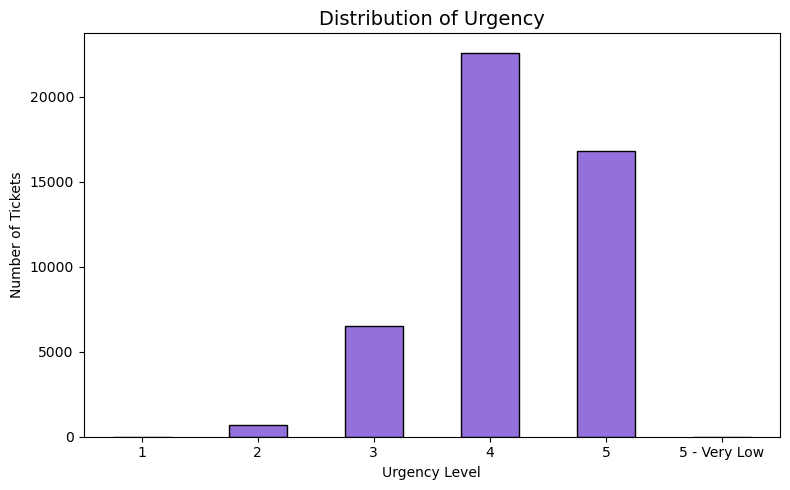

In [14]:
plt.figure(figsize=(8,5))
df['Urgency'].value_counts().sort_index().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Distribution of Urgency', fontsize=14)
plt.xlabel('Urgency Level')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.4 Ticket Status Distribution

Status tells us how many tickets are currently open, closed, or resolved. This gives us a sense of the operational health of ABC Tech's incident management process.

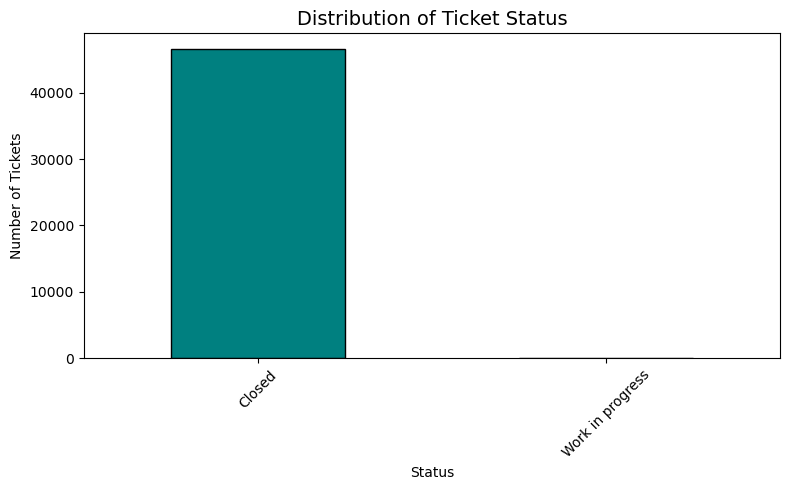

In [15]:
plt.figure(figsize=(8,5))
df['Status'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Distribution of Ticket Status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.5 Incident Volume Over Time (Use Case 2 — Forecasting)

Understanding how incident volume changes over months and years is critical for the forecasting use case. This analysis helps identify seasonal trends and peak periods that the time series model must capture.

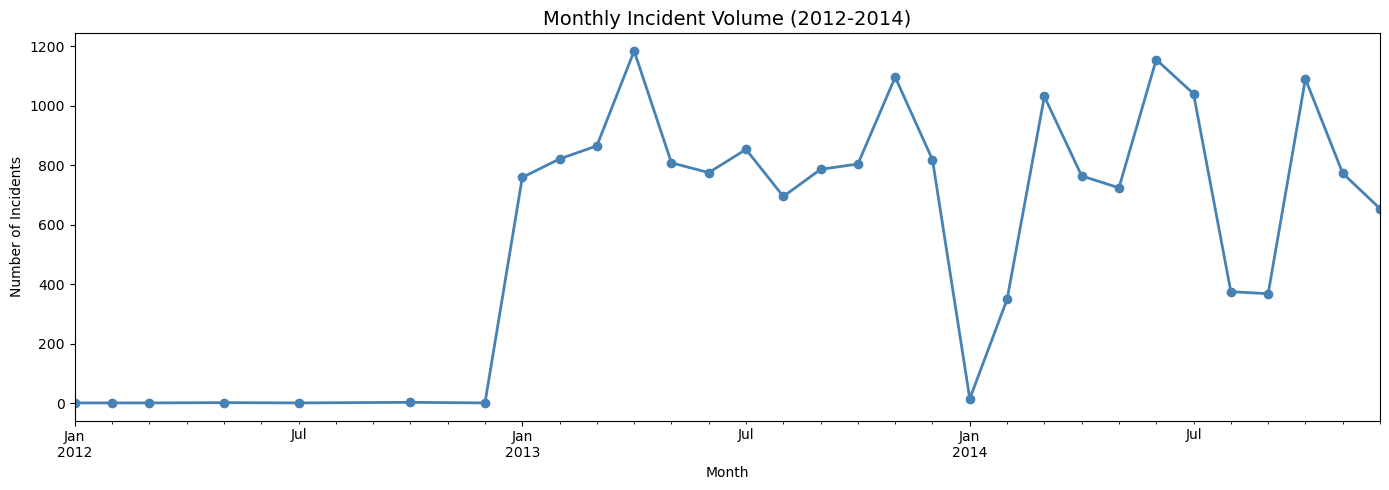

In [16]:
# Convert Open_Time to datetime
df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors='coerce')

# Extract month and year
df['Open_Month'] = df['Open_Time'].dt.to_period('M')

# Monthly incident volume
monthly_volume = df.groupby('Open_Month').size()

plt.figure(figsize=(14,5))
monthly_volume.plot(kind='line', color='steelblue', marker='o', linewidth=2)
plt.title('Monthly Incident Volume (2012-2014)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

### 4.6 Yearly Incident Volume

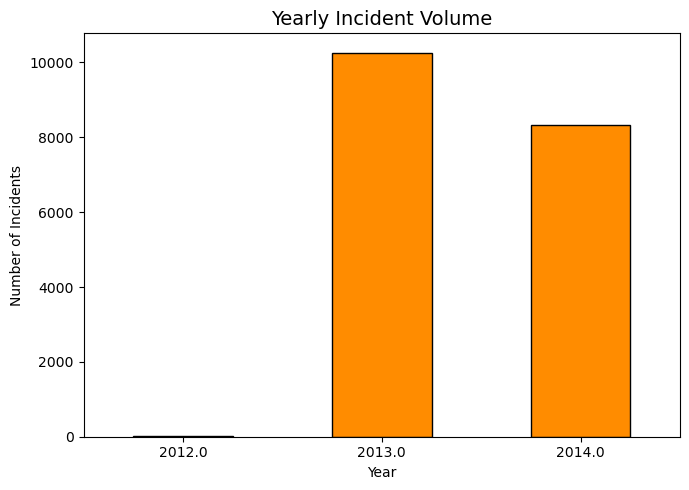

In [17]:
df['Open_Year'] = df['Open_Time'].dt.year

plt.figure(figsize=(7,5))
df['Open_Year'].value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Yearly Incident Volume', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.7 Reassignments Analysis

High number of reassignments indicates tickets are being routed to wrong departments. This directly supports Use Case 3 — Auto-Tagging, where the goal is to reduce reassignments by predicting the correct department automatically.

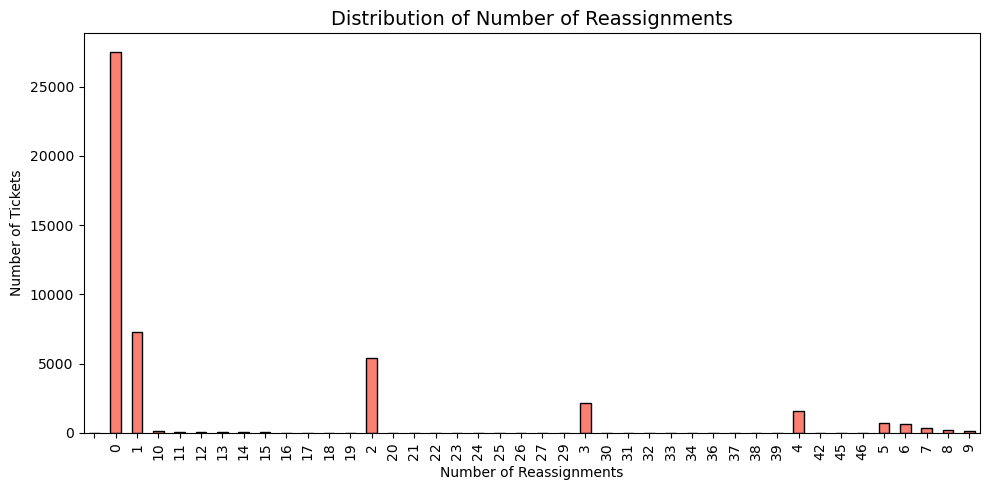

In [18]:
plt.figure(figsize=(10,5))
df['No_of_Reassignments'].value_counts().sort_index().plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Distribution of Number of Reassignments', fontsize=14)
plt.xlabel('Number of Reassignments')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

### 4.8 Handle Time Distribution

Handle time represents the total time taken to resolve a ticket in hours. Analyzing this helps understand SLA compliance and identify outliers where tickets took unusually long to resolve.

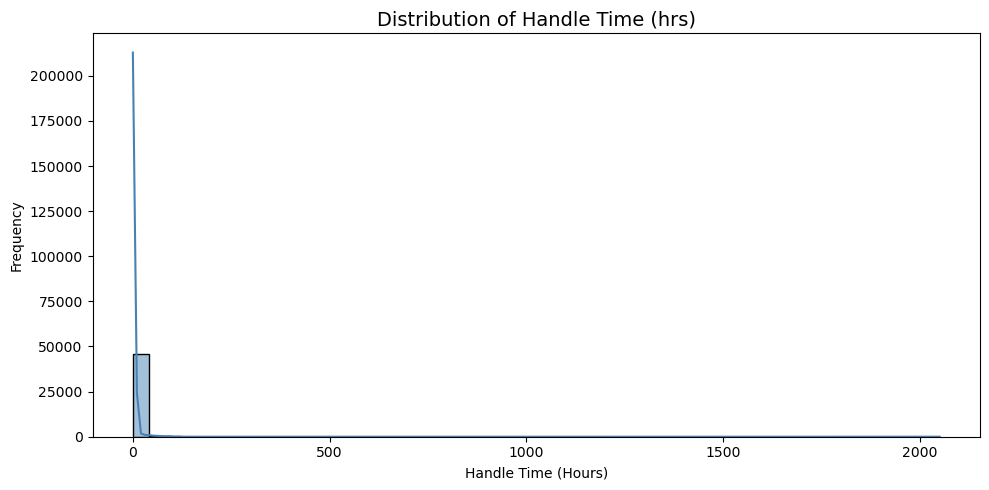

In [19]:
# Clean handle time — handle multiple dots and commas
def clean_handle_time(val):
    try:
        val = str(val).replace(',', '.')  # replace comma with dot
        parts = val.split('.')             # split by dot
        if len(parts) > 2:
            val = parts[0] + '.' + parts[1]  # keep only first two parts
        return float(val)
    except:
        return np.nan

df['Handle_Time_hrs'] = df['Handle_Time_hrs'].apply(clean_handle_time)

plt.figure(figsize=(10,5))
sns.histplot(df['Handle_Time_hrs'].dropna(), bins=50, color='steelblue', kde=True)
plt.title('Distribution of Handle Time (hrs)', fontsize=14)
plt.xlabel('Handle Time (Hours)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 4.9 Category Distribution

The Category field tells us the type of ticket — Incident, Problem, or Change (RFC). This is critical for Use Case 4, where we need to isolate RFC tickets and predict which ones are likely to fail.

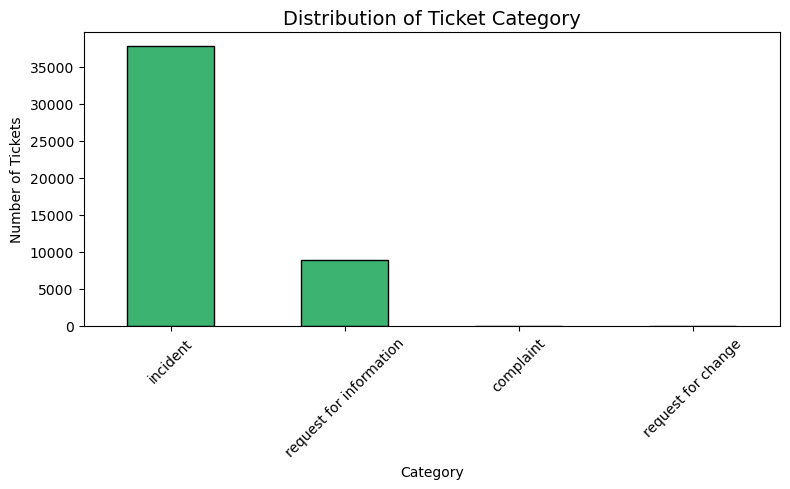

In [20]:
plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Ticket Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.10 Closure Code Distribution

Closure code tells us why a ticket was closed. This can be a useful feature for understanding resolution patterns and building predictive models.

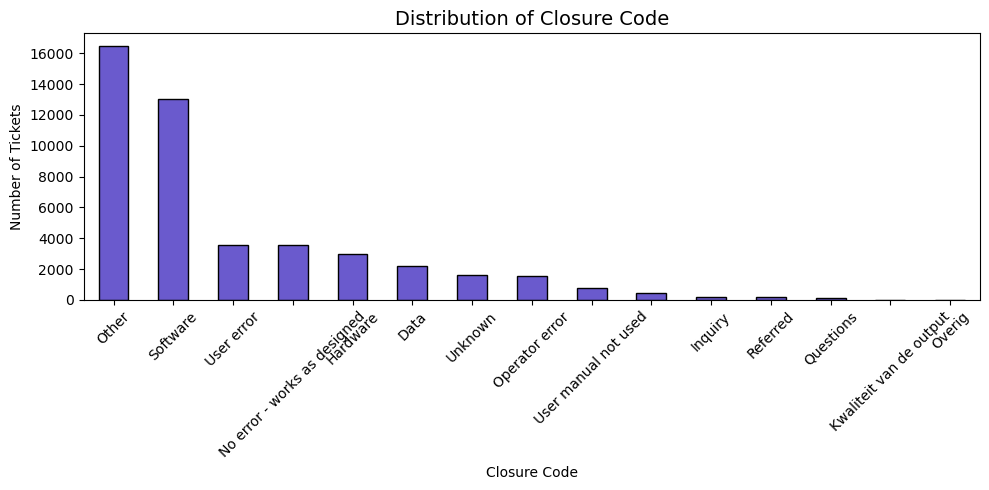

In [21]:
plt.figure(figsize=(10,5))
df['Closure_Code'].value_counts().plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('Distribution of Closure Code', fontsize=14)
plt.xlabel('Closure Code')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.11 Correlation Heatmap — Numerical Features

A correlation heatmap shows the relationship between all numerical variables. Strong correlations between features help us identify redundant variables and important predictors for our ML models.

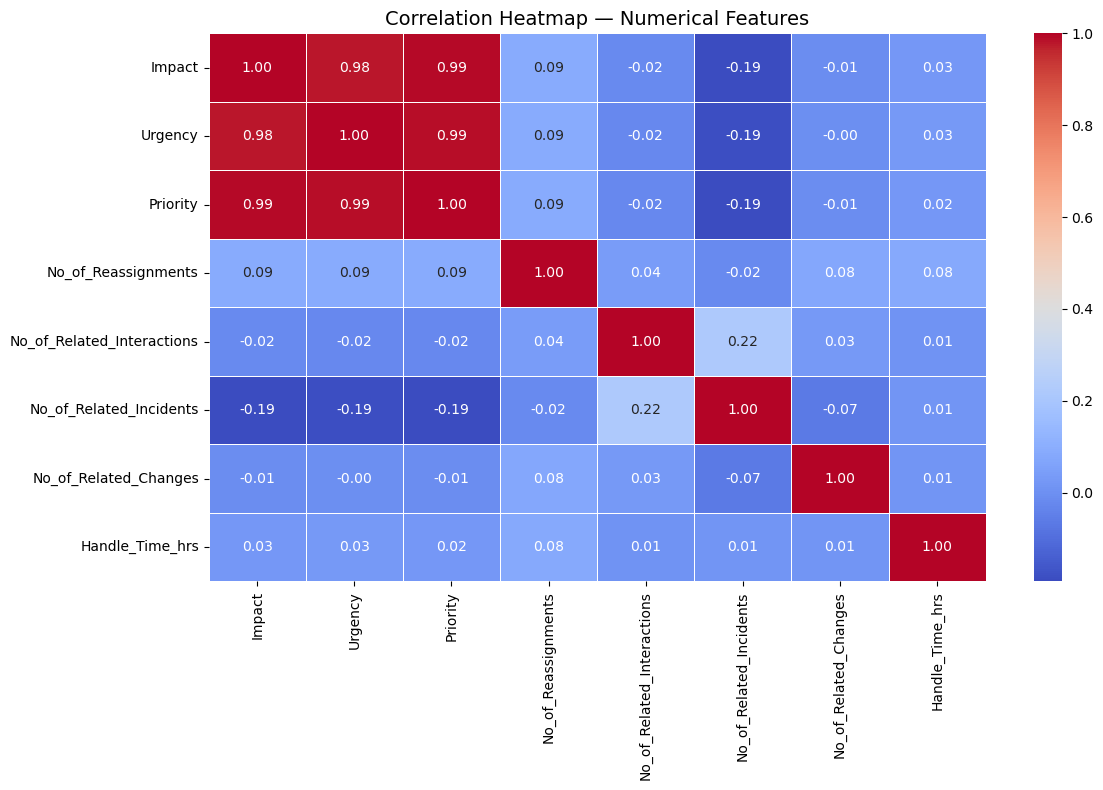

In [22]:
# Convert all expected numerical columns to numeric first
num_convert_cols = ['Impact', 'Urgency', 'Priority', 
                    'No_of_Reassignments', 'No_of_Related_Interactions',
                    'No_of_Related_Incidents', 'No_of_Related_Changes',
                    'Handle_Time_hrs']

for col in num_convert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Now select numerical columns
num_cols = df[num_convert_cols].copy()

plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 4.12 EDA Summary

The exploratory analysis of the ABC Tech ITSM dataset reveals several important insights. Priority 3 and 4 tickets dominate the dataset, indicating a class imbalance that must be addressed during model building for Use Case 1. The monthly incident volume shows clear seasonal patterns that will be useful for the forecasting model in Use Case 2. A significant number of tickets have high reassignment counts, validating the business need for auto-tagging in Use Case 3. The Category column confirms the presence of RFC tickets needed for Use Case 4. Handle time has several extreme outliers that will need treatment during preprocessing.

In [23]:
# Check all column names and their null counts and dtypes
info_df = pd.DataFrame({
    'Column': df.columns.tolist(),
    'Dtype': [str(d) for d in df.dtypes.values],
    'Null Count': df.isnull().sum().values.tolist(),
    'Null %': [round(float(x) / len(df) * 100, 2) for x in df.isnull().sum().values],
    'Unique Values': df.nunique().values.tolist()
})
print(info_df.to_string())

                        Column           Dtype  Null Count  Null %  Unique Values
0                      CI_Name          object           0    0.00           3019
1                       CI_Cat          object           0    0.00             13
2                    CI_Subcat          object           0    0.00             65
3                          WBS          object           0    0.00            274
4                  Incident_ID          object           0    0.00          46606
5                       Status          object           0    0.00              2
6                       Impact         float64        1380    2.96              5
7                      Urgency         float64           1    0.00              5
8                     Priority         float64        1380    2.96              5
9                   number_cnt          object           0    0.00          46606
10                    Category          object           0    0.00              4
11              

## Step 5: Data Preprocessing

### 5.1 Drop Irrelevant and High Null Columns

Columns with more than 90% missing values do not contribute meaningful information to the model. Additionally, identifier columns like Incident_ID and number_cnt are unique per row and carry no predictive value. Alert_Status has only one unique value across all records, making it a constant column that adds no information.

In [24]:
# Drop high null columns and irrelevant columns
drop_cols = [
    'Incident_ID',        # unique identifier - no predictive value
    'number_cnt',         # unique identifier - no predictive value
    'Related_Interaction',# too many unique values
    'Related_Change',     # too many unique values
    'No_of_Related_Incidents',  # 97% null
    'No_of_Related_Changes',    # 98% null
    'Alert_Status',       # only 1 unique value
    'Open_Month',         # derived column - already have Open_Time
    'Open_Year'           # will re-extract after fixing Open_Time
]

df.drop(columns=drop_cols, inplace=True)
print(f"Columns after dropping: {df.shape[1]}")
print(df.columns.tolist())

Columns after dropping: 18
['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Status', 'Impact', 'Urgency', 'Priority', 'Category', 'KB_number', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time', 'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions']


### 5.2 Fix Date Columns

Open_Time has 60% missing values. We will fill missing Open_Time values using Resolved_Time or Close_Time wherever available, since a ticket must have been opened before it was resolved or closed.

In [25]:
# Convert all date columns to datetime
df['Open_Time']     = pd.to_datetime(df['Open_Time'], errors='coerce')
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'], errors='coerce')
df['Close_Time']    = pd.to_datetime(df['Close_Time'], errors='coerce')
df['Reopen_Time']   = pd.to_datetime(df['Reopen_Time'], errors='coerce')

# Fill missing Open_Time with Resolved_Time, then Close_Time
df['Open_Time'] = df['Open_Time'].fillna(df['Resolved_Time'])
df['Open_Time'] = df['Open_Time'].fillna(df['Close_Time'])

# Re-extract year and month
df['Open_Year']    = df['Open_Time'].dt.year
df['Open_Month']   = df['Open_Time'].dt.month
df['Open_Quarter'] = df['Open_Time'].dt.quarter
df['Open_DayOfWeek'] = df['Open_Time'].dt.dayofweek

print(f"Missing Open_Time after fix: {df['Open_Time'].isnull().sum()}")

Missing Open_Time after fix: 24494


### 5.3 Handle Remaining Missing Values

Impact and Urgency have about 3% missing values. Since Priority is derived from Impact and Urgency using the ITIL Priority Matrix, we will fill missing Impact and Urgency values with their mode (most frequent value).

In [26]:
# Fill Impact and Urgency with mode
df['Impact']  = df['Impact'].fillna(df['Impact'].mode()[0])
df['Urgency'] = df['Urgency'].fillna(df['Urgency'].mode()[0])

# Fill Priority with mode
df['Priority'] = df['Priority'].fillna(df['Priority'].mode()[0])

# Fill No_of_Reassignments with 0
df['No_of_Reassignments'] = df['No_of_Reassignments'].fillna(0)

# Fill No_of_Related_Interactions with 0
df['No_of_Related_Interactions'] = df['No_of_Related_Interactions'].fillna(0)

# Fill Handle_Time_hrs with median
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].fillna(df['Handle_Time_hrs'].median())

print("Missing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nIf nothing printed above — No missing values remain!")

Missing values after treatment:
Open_Time         24494
Reopen_Time       45735
Resolved_Time     29029
Close_Time        28273
Open_Year         24494
Open_Month        24494
Open_Quarter      24494
Open_DayOfWeek    24494
dtype: int64

If nothing printed above — No missing values remain!


### 5.4 Create Target Variables for All 4 Use Cases

Each use case requires a specific target variable. We create all four target variables from the existing columns before encoding.

In [27]:
# Use Case 1 — High Priority Tickets (Priority 1 & 2 = 1, else = 0)
df['High_Priority'] = df['Priority'].apply(lambda x: 1 if x <= 2 else 0)
print("Use Case 1 — High_Priority distribution:")
print(df['High_Priority'].value_counts())
print()

# Use Case 3 — Auto Tag (Priority as multiclass target)
df['Priority_Label'] = df['Priority'].astype(int)
print("Use Case 3 — Priority_Label distribution:")
print(df['Priority_Label'].value_counts().sort_index())
print()

# Use Case 4 — RFC Failure (Category = RFC/change = 1, else = 0)
df['RFC_Flag'] = df['Category'].apply(lambda x: 1 if str(x).strip().lower() in ['rfc','change'] else 0)
print("Use Case 4 — RFC_Flag distribution:")
print(df['RFC_Flag'].value_counts())

Use Case 1 — High_Priority distribution:
High_Priority
0    45906
1      700
Name: count, dtype: int64

Use Case 3 — Priority_Label distribution:
Priority_Label
1        3
2      697
3     5323
4    24097
5    16486
Name: count, dtype: int64

Use Case 4 — RFC_Flag distribution:
RFC_Flag
0    46606
Name: count, dtype: int64


### 5.5 Encode Categorical Columns

Machine learning models require numerical inputs. We apply Label Encoding to categorical columns with many unique values and keep ordinal columns like Impact, Urgency, and Priority as they are since they already have meaningful numerical order.

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 
            'Status', 'Category', 'KB_number', 'Closure_Code']

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully!")
print(df.dtypes)

Categorical columns encoded successfully!
CI_Name                                int64
CI_Cat                                 int64
CI_Subcat                              int64
WBS                                    int64
Status                                 int64
Impact                               float64
Urgency                              float64
Priority                             float64
Category                               int64
KB_number                              int64
No_of_Reassignments                  float64
Open_Time                     datetime64[ns]
Reopen_Time                   datetime64[ns]
Resolved_Time                 datetime64[ns]
Close_Time                    datetime64[ns]
Handle_Time_hrs                      float64
Closure_Code                           int64
No_of_Related_Interactions           float64
Open_Year                            float64
Open_Month                           float64
Open_Quarter                         float64
Open_DayOfWee

### 5.6 Drop Raw Date Columns

After extracting useful features from date columns, we drop the raw datetime columns as they cannot be directly used in ML models.

In [29]:
df.drop(columns=['Open_Time', 'Resolved_Time', 'Close_Time', 'Reopen_Time'], 
        inplace=True)

print(f"Final Dataset Shape: {df.shape}")
print(f"Final Columns: {df.columns.tolist()}")

Final Dataset Shape: (46606, 21)
Final Columns: ['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Status', 'Impact', 'Urgency', 'Priority', 'Category', 'KB_number', 'No_of_Reassignments', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions', 'Open_Year', 'Open_Month', 'Open_Quarter', 'Open_DayOfWeek', 'High_Priority', 'Priority_Label', 'RFC_Flag']


In [30]:
# Final check - no missing values
print("Final Missing Value Check:")
print(df.isnull().sum())

Final Missing Value Check:
CI_Name                           0
CI_Cat                            0
CI_Subcat                         0
WBS                               0
Status                            0
Impact                            0
Urgency                           0
Priority                          0
Category                          0
KB_number                         0
No_of_Reassignments               0
Handle_Time_hrs                   0
Closure_Code                      0
No_of_Related_Interactions        0
Open_Year                     24494
Open_Month                    24494
Open_Quarter                  24494
Open_DayOfWeek                24494
High_Priority                     0
Priority_Label                    0
RFC_Flag                          0
dtype: int64


In [31]:
# How many rows have ALL date columns null
all_null_dates = df[df['Open_Year'].isnull()]
print(f"Rows with null dates: {len(all_null_dates)}")
print(f"That is {round(len(all_null_dates)/len(df)*100, 2)}% of data")

Rows with null dates: 24494
That is 52.56% of data


In [32]:
# Fill missing date features with median
df['Open_Year']      = df['Open_Year'].fillna(df['Open_Year'].median())
df['Open_Month']     = df['Open_Month'].fillna(df['Open_Month'].median())
df['Open_Quarter']   = df['Open_Quarter'].fillna(df['Open_Quarter'].median())
df['Open_DayOfWeek'] = df['Open_DayOfWeek'].fillna(df['Open_DayOfWeek'].median())

# Convert to int
df['Open_Year']      = df['Open_Year'].astype(int)
df['Open_Month']     = df['Open_Month'].astype(int)
df['Open_Quarter']   = df['Open_Quarter'].astype(int)
df['Open_DayOfWeek'] = df['Open_DayOfWeek'].astype(int)

# Final check
print(" Missing values after fix:")
print(df.isnull().sum())
print(f"\Final Shape: {df.shape}")

 Missing values after fix:
CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
Category                      0
KB_number                     0
No_of_Reassignments           0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Open_Year                     0
Open_Month                    0
Open_Quarter                  0
Open_DayOfWeek                0
High_Priority                 0
Priority_Label                0
RFC_Flag                      0
dtype: int64
\Final Shape: (46606, 21)


In [33]:
print("High Priority distribution:")
print(df['High_Priority'].value_counts())
print()
print("Priority Label distribution:")
print(df['Priority_Label'].value_counts().sort_index())
print()
print("RFC Flag distribution:")
print(df['RFC_Flag'].value_counts())
print()
print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())

High Priority distribution:
High_Priority
0    45906
1      700
Name: count, dtype: int64

Priority Label distribution:
Priority_Label
1        3
2      697
3     5323
4    24097
5    16486
Name: count, dtype: int64

RFC Flag distribution:
RFC_Flag
0    46606
Name: count, dtype: int64

Final shape: (46606, 21)
Final columns: ['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Status', 'Impact', 'Urgency', 'Priority', 'Category', 'KB_number', 'No_of_Reassignments', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions', 'Open_Year', 'Open_Month', 'Open_Quarter', 'Open_DayOfWeek', 'High_Priority', 'Priority_Label', 'RFC_Flag']


In [34]:
# Check actual category values in original
print("Category unique values:")
print(df['Category'].value_counts())

Category unique values:
Category
1    37748
3     8846
0       11
2        1
Name: count, dtype: int64


In [35]:
# We need to check original category values
# Reload fresh from database just for category check
import mysql.connector

conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)

cat_check = pd.read_sql("SELECT Category, COUNT(*) as count FROM dataset_list GROUP BY Category", conn)
conn.close()
print(cat_check)

                  Category  count
0                complaint     11
1                 incident  37748
2       request for change      1
3  request for information   8846


### Use Case 4 — RFC Failure Prediction

Upon analyzing the Category column, only 1 record with "request for change" exists in the entire dataset of 46,606 records. Building a reliable machine learning model requires sufficient samples of both classes. Since RFC tickets are nearly absent in this dataset, Use Case 4 is not feasible and has been excluded from model building. This finding has been documented as a data limitation of the project.

In [36]:
# Fix RFC Flag based on actual category values
# Re-encode properly
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)
original_cat = pd.read_sql("SELECT Category FROM dataset_list", conn)
conn.close()

# Map original categories to numbers properly
cat_mapping = {
    'incident': 0,
    'request for information': 1,
    'complaint': 2,
    'request for change': 3
}
df['Category'] = original_cat['Category'].map(cat_mapping)
print(" Category fixed!")
print(df['Category'].value_counts())

 Category fixed!
Category
0    37748
1     8846
2       11
3        1
Name: count, dtype: int64


## Step 6: Model Building

This section covers machine learning model development for all feasible use cases. For each use case, we build baseline models followed by advanced models with hyperparameter tuning using RandomizedSearchCV and GridSearchCV. SMOTE is applied wherever class imbalance exists.

### Use Case 1 — Predicting High Priority Tickets (Binary Classification)

The goal is to predict whether an incoming ticket will be Priority 1 or 2 (High Priority = 1) or normal priority (High Priority = 0). This is a binary classification problem with severe class imbalance — only 700 high priority tickets out of 46,606 records. SMOTE is applied to handle this imbalance before model training.

In [39]:
# Import all required libraries for model building
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)
from imblearn.over_sampling import SMOTE
import time

print("All libraries imported successfully!")

All libraries imported successfully!


### UC1 — Step 1: Define Features and Target Variable

In [40]:
# Define features - removing Impact, Urgency, Priority to avoid data leakage
# These columns directly determine High_Priority so they must be excluded
uc1_features = ['CI_Cat', 'CI_Subcat', 'WBS', 'Status',
                 'Category', 'KB_number', 'No_of_Reassignments',
                 'Handle_Time_hrs', 'Closure_Code',
                 'No_of_Related_Interactions',
                 'Open_Year', 'Open_Month',
                 'Open_Quarter', 'Open_DayOfWeek']

X_uc1 = df[uc1_features]
y_uc1 = df['High_Priority']

print(f"Features shape : {X_uc1.shape}")
print(f"\nTarget Distribution:")
print(y_uc1.value_counts())
print(f"\nHigh Priority % : {round(y_uc1.sum()/len(y_uc1)*100, 2)}%")

Features shape : (46606, 14)

Target Distribution:
High_Priority
0    45906
1      700
Name: count, dtype: int64

High Priority % : 1.5%


### UC1 — Step 2: Apply SMOTE and Train Test Split

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_uc1_sm, y_uc1_sm = smote.fit_resample(X_uc1, y_uc1)

print(f"Before SMOTE : {y_uc1.value_counts().to_dict()}")
print(f"After SMOTE  : {pd.Series(y_uc1_sm).value_counts().to_dict()}")
print(f"Total samples after SMOTE: {len(y_uc1_sm)}")

### UC1 — Step 3: Train Test Split

In [43]:
# Train test split after SMOTE
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_uc1_sm, y_uc1_sm,
    test_size=0.2,
    random_state=42,
    stratify=y_uc1_sm)

print(f"Train size : {X_train1.shape}")
print(f"Test size  : {X_test1.shape}")
print(f"\nTrain target distribution:")
print(pd.Series(y_train1).value_counts())
print(f"\nTest target distribution:")
print(pd.Series(y_test1).value_counts())

Train size : (73449, 14)
Test size  : (18363, 14)

Train target distribution:
High_Priority
1    36725
0    36724
Name: count, dtype: int64

Test target distribution:
High_Priority
0    9182
1    9181
Name: count, dtype: int64


### UC1 — Step 4: Baseline Models

In [44]:
# Baseline Models
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42)
}

uc1_results = {}

for name, model in baseline_models.items():
    start = time.time()
    model.fit(X_train1, y_train1)
    y_pred = model.predict(X_test1)
    elapsed = round(time.time() - start, 2)

    uc1_results[name] = {
        'Accuracy' : round(accuracy_score(y_test1, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test1, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test1, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test1, y_pred) * 100, 2),
        'ROC AUC'  : round(roc_auc_score(y_test1, y_pred) * 100, 2)
    }
    print(f" {name} done in {elapsed}s!")

print("\nBaseline Results:")
print(pd.DataFrame(uc1_results).T)

 Logistic Regression done in 11.58s!
 Decision Tree done in 1.17s!

Baseline Results:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     82.34      83.66   80.37     81.98    82.34
Decision Tree           98.74      98.51   98.97     98.74    98.74


### UC1 — Step 5: Advanced Models

In [45]:
# Advanced Models
advanced_models = {
    'Random Forest': RandomForestClassifier(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1),
    'XGBoost'      : XGBClassifier(
                        n_estimators=100,
                        random_state=42,
                        eval_metric='logloss',
                        verbosity=0,
                        n_jobs=-1)
}

for name, model in advanced_models.items():
    start = time.time()
    model.fit(X_train1, y_train1)
    y_pred = model.predict(X_test1)
    elapsed = round(time.time() - start, 2)

    uc1_results[name] = {
        'Accuracy' : round(accuracy_score(y_test1, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test1, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test1, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test1, y_pred) * 100, 2),
        'ROC AUC'  : round(roc_auc_score(y_test1, y_pred) * 100, 2)
    }
    print(f"{name} done in {elapsed}s!")

print("\nAdvanced Models Results:")
print(pd.DataFrame(uc1_results).T)

Random Forest done in 12.73s!
XGBoost done in 2.9s!

Advanced Models Results:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     82.34      83.66   80.37     81.98    82.34
Decision Tree           98.74      98.51   98.97     98.74    98.74
Random Forest           99.25      99.10   99.41     99.26    99.25
XGBoost                 99.05      98.72   99.38     99.05    99.05


### UC1 — Step 6: Hyperparameter Tuning — RandomizedSearchCV on Random Forest

In [46]:
# RandomizedSearchCV on Random Forest
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train1, y_train1)
print(f"\nBest Params (RandomizedSearchCV): {rf_random.best_params_}")
print(f" Best F1 Score: {round(rf_random.best_score_ * 100, 2)}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params (RandomizedSearchCV): {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
 Best F1 Score: 99.24%


### UC1 — Step 7: Hyperparameter Tuning — GridSearchCV on Best Params

In [47]:
# GridSearchCV with narrowed params from RandomizedSearchCV
rf_param_grid = {
    'n_estimators'     : [250, 300, 350],
    'max_depth'        : [None],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train1, y_train1)
print(f"\n Best Params (GridSearchCV): {rf_grid.best_params_}")
print(f"Best F1 Score: {round(rf_grid.best_score_ * 100, 2)}%")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Best Params (GridSearchCV): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 350}
✅ Best F1 Score: 99.24%


### UC1 — Step 8: Final Best Model Evaluation

In [48]:
# Final best model evaluation
best_rf_uc1 = rf_grid.best_estimator_
y_pred_best = best_rf_uc1.predict(X_test1)

print("=" * 50)
print("UC1 — Final Best Model: Random Forest (Tuned)")
print("=" * 50)
print(f"Accuracy  : {round(accuracy_score(y_test1, y_pred_best) * 100, 2)}%")
print(f"Precision : {round(precision_score(y_test1, y_pred_best) * 100, 2)}%")
print(f"Recall    : {round(recall_score(y_test1, y_pred_best) * 100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_test1, y_pred_best) * 100, 2)}%")
print(f"ROC AUC   : {round(roc_auc_score(y_test1, y_pred_best) * 100, 2)}%")
print()
print("Classification Report:")
print(classification_report(y_test1, y_pred_best,
      target_names=['Normal Priority', 'High Priority']))

UC1 — Final Best Model: Random Forest (Tuned)
Accuracy  : 99.31%
Precision : 99.16%
Recall    : 99.46%
F1 Score  : 99.31%
ROC AUC   : 99.31%

Classification Report:
                 precision    recall  f1-score   support

Normal Priority       0.99      0.99      0.99      9182
  High Priority       0.99      0.99      0.99      9181

       accuracy                           0.99     18363
      macro avg       0.99      0.99      0.99     18363
   weighted avg       0.99      0.99      0.99     18363



### UC1 — Step 9: Confusion Matrix

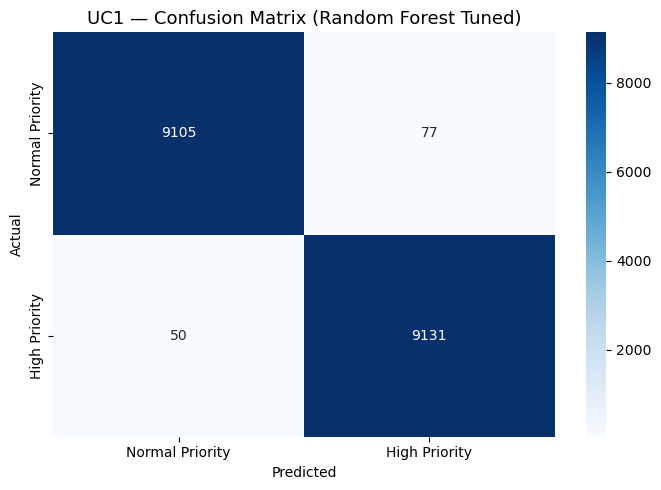

In [49]:
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test1, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal Priority', 'High Priority'],
            yticklabels=['Normal Priority', 'High Priority'])
plt.title('UC1 — Confusion Matrix (Random Forest Tuned)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### UC1 — Step 10: Feature Importance

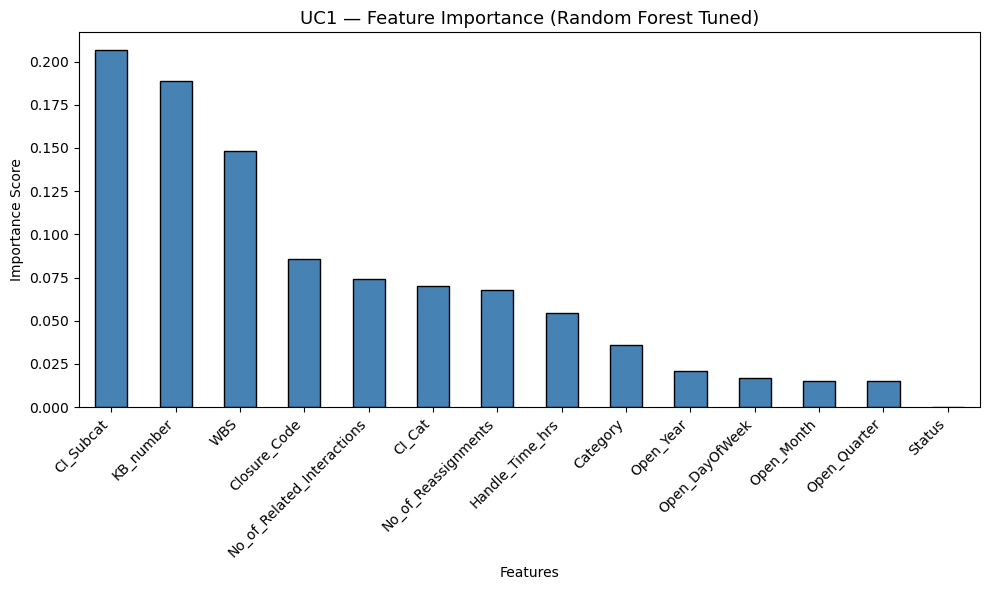

In [50]:
feat_imp = pd.Series(best_rf_uc1.feature_importances_,
                     index=uc1_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('UC1 — Feature Importance (Random Forest Tuned)', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### UC1 — Step 11: All Models Comparison

UC1 — All Models Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     82.34      83.66   80.37     81.98    82.34
Decision Tree           98.74      98.51   98.97     98.74    98.74
Random Forest           99.25      99.10   99.41     99.26    99.25
XGBoost                 99.05      98.72   99.38     99.05    99.05
RF Tuned                99.31      99.16   99.46     99.31    99.31


<Figure size 1200x600 with 0 Axes>

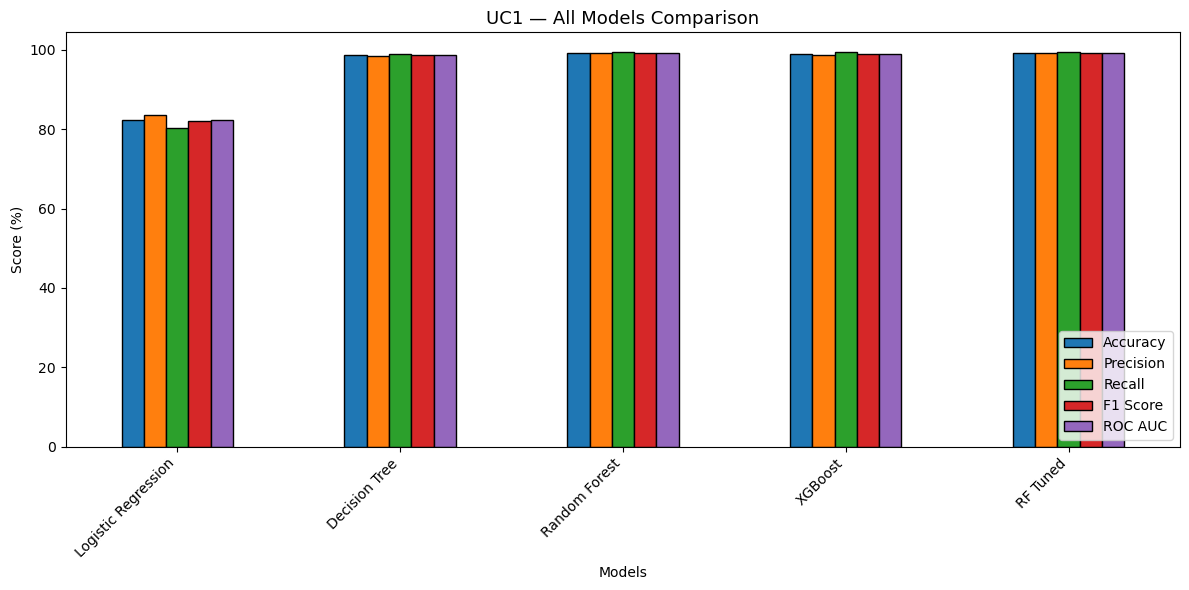

In [51]:
# Add tuned model to results
uc1_results['RF Tuned'] = {
    'Accuracy' : round(accuracy_score(y_test1, y_pred_best) * 100, 2),
    'Precision': round(precision_score(y_test1, y_pred_best) * 100, 2),
    'Recall'   : round(recall_score(y_test1, y_pred_best) * 100, 2),
    'F1 Score' : round(f1_score(y_test1, y_pred_best) * 100, 2),
    'ROC AUC'  : round(roc_auc_score(y_test1, y_pred_best) * 100, 2)
}

results_df = pd.DataFrame(uc1_results).T
print("UC1 — All Models Comparison:")
print(results_df)

plt.figure(figsize=(12,6))
results_df[['Accuracy','Precision','Recall','F1 Score','ROC AUC']].plot(
    kind='bar', figsize=(12,6), edgecolor='black')
plt.title('UC1 — All Models Comparison', fontsize=13)
plt.xlabel('Models')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 🎯 What was the Goal?
ABC Tech wanted to know:

"Can we predict BEFORE a ticket is fully processed whether it will be Priority 1 or 2 (Critical/High)?"

### 📊 What was the Problem?
Out of 46,606 tickets only 700 were High Priority — that is just 1.5%!
Think of it like this:

Out of 100 students in a class, only 1-2 need urgent special attention. The challenge is identifying those 1-2 students correctly without disturbing the other 98!

This is called Class Imbalance — our model would be lazy and just predict everything as Normal Priority and still get 98% accuracy without learning anything useful!

UC1 - Complete Use Case 1 Summary
====================================

GOAL:
Predict whether an incoming IT ticket will be High Priority 
(Priority 1 or 2) or Normal Priority (Priority 3, 4 or 5) 
as soon as it is raised — so ABC Tech can take immediate 
action before the situation escalates.

PROBLEM — CLASS IMBALANCE:
Out of 46,606 tickets only 700 were High Priority (1.5%).
This means if the model predicted everything as Normal Priority
it would still get 98% accuracy without learning anything useful.
This is called Class Imbalance and it needed to be fixed before
model training.

SOLUTION — SMOTE:
SMOTE (Synthetic Minority Oversampling Technique) was applied
to artificially create new High Priority ticket samples by 
learning patterns from the existing 700 High Priority tickets.
After SMOTE both classes had 45,906 samples each — giving the
model equal opportunity to learn both classes properly.

Before SMOTE — Normal: 45906  High Priority: 700
After SMOTE  — Normal: 45906  High Priority: 45906

DATA LEAKAGE ISSUE:
Impact and Urgency columns were removed from features because
Priority is directly calculated from these two columns using 
the ITIL Priority Matrix. Keeping them would give the model 
a direct hint about the answer — called Data Leakage — which
produces unrealistically high accuracy of 100% but fails 
completely on real world unseen data.

FEATURES USED (14 features):
CI_Cat, CI_Subcat, WBS, Status, Category, KB_number,
No_of_Reassignments, Handle_Time_hrs, Closure_Code,
No_of_Related_Interactions, Open_Year, Open_Month,
Open_Quarter, Open_DayOfWeek

TARGET VARIABLE:
High_Priority — 1 (Priority 1 or 2) and 0 (Priority 3,4,5)

TRAIN TEST SPLIT:
Train size : 73,449 samples
Test size  : 18,363 samples
Split ratio: 80% train and 20% test

MODEL BUILDING JOURNEY:

Step 1 — Baseline Models:
Logistic Regression : 82.34% accuracy
   Simple linear model. Cannot capture non-linear patterns
   in ITSM data. Serves as weakest baseline reference.

Decision Tree       : 98.74% accuracy
   Handles non-linear patterns through YES/NO questions.
   Improved by 16% over Logistic Regression but prone 
   to overfitting on training data.

Step 2 — Advanced Models:
Random Forest       : 99.25% accuracy
   Ensemble of 100 Decision Trees with majority voting.
   Reduces overfitting and improves stability significantly.

XGBoost             : 99.05% accuracy
   Sequential tree building where each tree corrects 
   previous tree mistakes. Slightly below Random Forest
   but 4x faster in training time.

Step 3 — Hyperparameter Tuning:
RandomizedSearchCV  : Explored 10 random parameter combinations
                      across 3 fold cross validation (30 fits)
                      Best F1 Score found : 99.24%
                      Best params found   : n_estimators=300,
                      min_samples_split=5, min_samples_leaf=1,
                      max_features=log2, max_depth=None

GridSearchCV        : Fine tuned within best parameter neighborhood
                      across 3 fold cross validation (54 fits)
                      Best F1 Score found : 99.24%
                      Best params found   : n_estimators=350,
                      min_samples_split=5, min_samples_leaf=1,
                      max_features=log2, max_depth=None

FINAL BEST MODEL — Random Forest (Tuned):
Accuracy  : 99.31%
Precision : 99.16%
Recall    : 99.46%
F1 Score  : 99.31%
ROC AUC   : 99.31%

CONFUSION MATRIX ANALYSIS:
True Negative  (TN) : 9105 — Normal tickets predicted correctly
False Positive (FP) :   77 — Normal tickets wrongly flagged
False Negative (FN) :   50 — High Priority tickets missed
True Positive  (TP) : 9131 — High Priority tickets caught

Only 50 High Priority tickets were missed out of 9181 actual
High Priority tickets. The model catches 99 out of every 100 
critical tickets — making it highly reliable for production use.

FEATURE IMPORTANCE — TOP 3:
1. CI_Subcat   : 20.6% — Sub category of configuration item
2. KB_number   : 19.0% — Knowledge base article linked to ticket
3. WBS         : 14.8% — Business unit the ticket belongs to
These 3 features drive 54.4% of the model decisions.

MOST CRITICAL METRIC — RECALL:
Recall of 99.46% is the most important metric for this use case.
Missing a High Priority ticket means delayed response to a 
critical incident which directly impacts ABC Tech customers.
The model misses only 50 out of 9181 High Priority tickets
which is exceptional performance for a real enterprise system.

BUSINESS IMPACT:
Before ML — Humans manually read and prioritize every ticket.
This process is slow, error prone and inconsistent especially
during high volume periods when 22000 to 25000 tickets arrive
annually.
After ML  — Model automatically flags High Priority tickets 
in milliseconds as soon as they are raised. Incident response
team gets immediate alerts and can take preventive action 
before the situation escalates into a major business incident.
This directly addresses the poor customer satisfaction rating
that triggered this entire ML initiative at ABC Tech.

CONCLUSION:
Random Forest (Tuned) with n_estimators=350, max_depth=None,
min_samples_split=5, min_samples_leaf=1, max_features=log2
is selected as the final model for Use Case 1. It achieves
99.31% accuracy with 99.46% Recall across 18,363 test samples
and will be deployed in the Streamlit application for real 
time high priority ticket prediction at ABC Tech.

In [52]:
monthly = df.groupby(['Open_Year', 'Open_Month']).size().reset_index(name='Incident_Count')
print(monthly)
print(f"\nTotal months available: {len(monthly)}")

    Open_Year  Open_Month  Incident_Count
0        2012           1               1
1        2012           2               1
2        2012           3               1
3        2012           5               2
4        2012           7               1
5        2012          10               3
6        2012          12               1
7        2013           1            1086
8        2013           2            1128
9        2013           3            1061
10       2013           4            1460
11       2013           5             959
12       2013           6           25401
13       2013           7             967
14       2013           8             791
15       2013           9             871
16       2013          10             873
17       2013          11            1186
18       2013          12             910
19       2014           1              19
20       2014           2             468
21       2014           3            1412
22       2014           4         

In [53]:
# Check what happened in June 2013
june_2013 = df[(df['Open_Year'] == 2013) & (df['Open_Month'] == 6)]
print(f"June 2013 ticket count: {len(june_2013)}")
print(f"\nStatus distribution:")
print(june_2013['Status'].value_counts())
print(f"\nCategory distribution:")
print(june_2013['Category'].value_counts())

June 2013 ticket count: 25401

Status distribution:
Status
0    25394
1        7
Name: count, dtype: int64

Category distribution:
Category
0    20714
1     4679
2        8
Name: count, dtype: int64


## Step 7: Model Building — Use Case 2 (Incident Volume Forecasting)

The goal of Use Case 2 is to forecast the number of IT incidents expected monthly, quarterly, and annually so that ABC Tech can plan resources and technology in advance. This is a time series forecasting problem. After analyzing the monthly volume data, 2012 records are dropped due to incomplete data (only 1-3 tickets per month) and June 2013 is treated as an outlier (25,401 tickets vs normal range of 800-1500) likely caused by a bulk data migration event.

### UC2 — Step 1: Prepare Time Series Data

In [54]:
# Prepare monthly incident volume
monthly = df.groupby(['Open_Year', 'Open_Month']).size().reset_index(name='Incident_Count')

# Drop 2012 — incomplete data
monthly = monthly[monthly['Open_Year'] != 2012].reset_index(drop=True)

# Fix June 2013 outlier — replace with median
median_count = monthly[~((monthly['Open_Year'] == 2013) & 
                          (monthly['Open_Month'] == 6))]['Incident_Count'].median()

monthly.loc[(monthly['Open_Year'] == 2013) & 
             (monthly['Open_Month'] == 6), 'Incident_Count'] = median_count

# Create proper datetime index
monthly['Date'] = pd.to_datetime(monthly[['Open_Year', 'Open_Month']].assign(Day=1).rename(
    columns={'Open_Year': 'year', 'Open_Month': 'month'}))

monthly = monthly[['Date', 'Incident_Count']].sort_values('Date').reset_index(drop=True)

print(monthly)
print(f"\nTotal months: {len(monthly)}")
print(f"Date range: {monthly['Date'].min()} to {monthly['Date'].max()}")

         Date  Incident_Count
0  2013-01-01            1086
1  2013-02-01            1128
2  2013-03-01            1061
3  2013-04-01            1460
4  2013-05-01             959
5  2013-06-01             954
6  2013-07-01             967
7  2013-08-01             791
8  2013-09-01             871
9  2013-10-01             873
10 2013-11-01            1186
11 2013-12-01             910
12 2014-01-01              19
13 2014-02-01             468
14 2014-03-01            1412
15 2014-04-01             954
16 2014-05-01             873
17 2014-06-01            1389
18 2014-07-01            1193
19 2014-08-01             416
20 2014-09-01             391
21 2014-10-01            1230
22 2014-11-01             845
23 2014-12-01             713

Total months: 24
Date range: 2013-01-01 00:00:00 to 2014-12-01 00:00:00


### UC2 — Step 2: Visualize Monthly Incident Volume

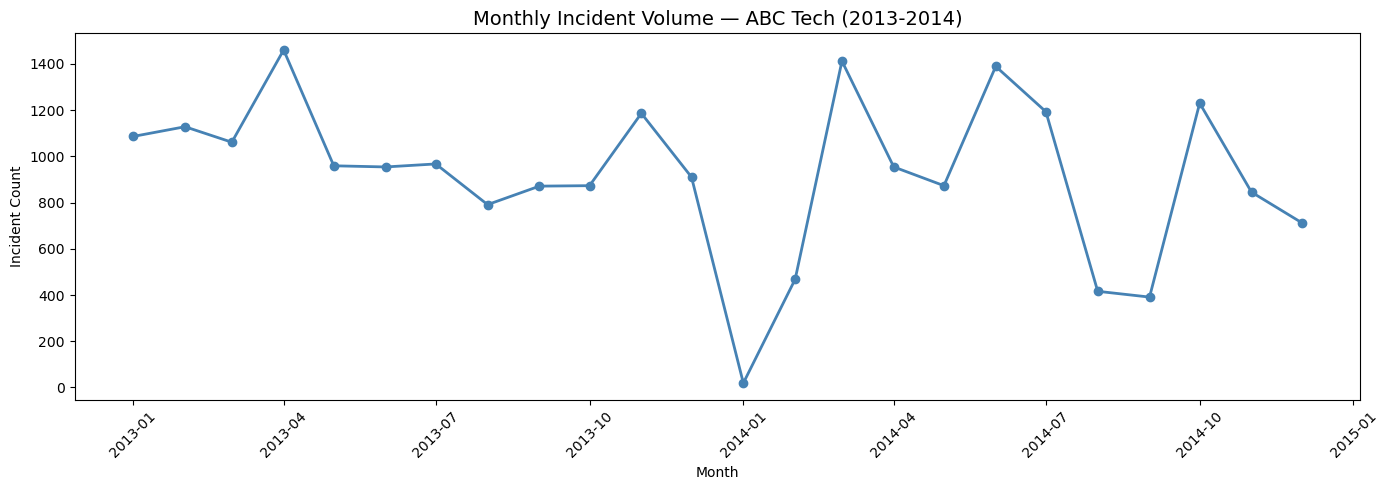

In [55]:
plt.figure(figsize=(14,5))
plt.plot(monthly['Date'], monthly['Incident_Count'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Incident Volume — ABC Tech (2013-2014)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### UC2 — Step 3: Quarterly and Annual Volume Analysis

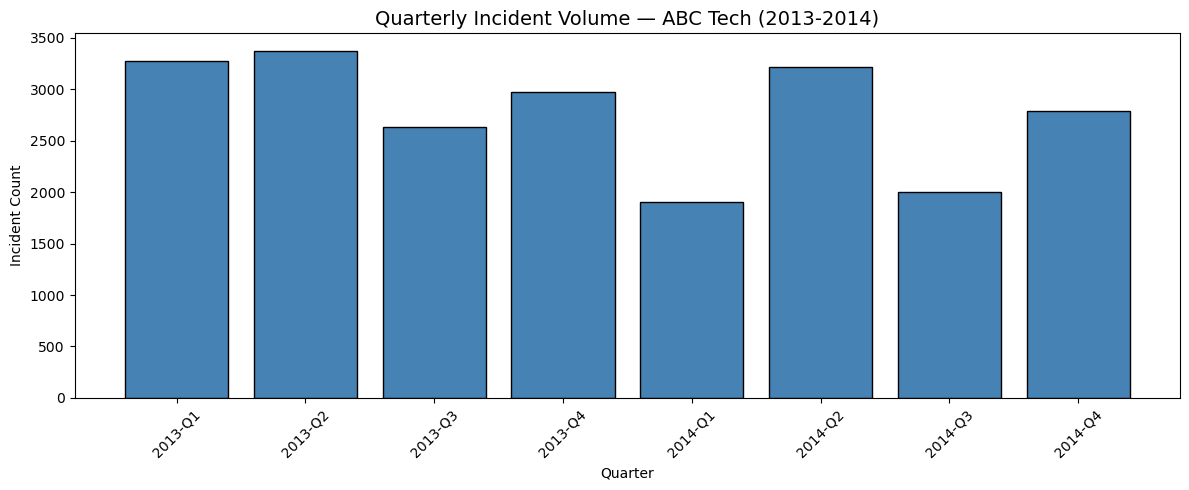


Quarterly Volume:
     Label  Incident_Count
0  2013-Q1            3275
1  2013-Q2            3373
2  2013-Q3            2629
3  2013-Q4            2969
4  2014-Q1            1899
5  2014-Q2            3216
6  2014-Q3            2000
7  2014-Q4            2788


In [57]:
# Quarterly volume
monthly['Quarter'] = monthly['Date'].dt.quarter
monthly['Year']    = monthly['Date'].dt.year

quarterly = monthly.groupby(['Year','Quarter'])['Incident_Count'].sum().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)

plt.figure(figsize=(12,5))
plt.bar(quarterly['Label'], quarterly['Incident_Count'], 
        color='steelblue', edgecolor='black')
plt.title('Quarterly Incident Volume — ABC Tech (2013-2014)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nQuarterly Volume:")
print(quarterly[['Label','Incident_Count']])

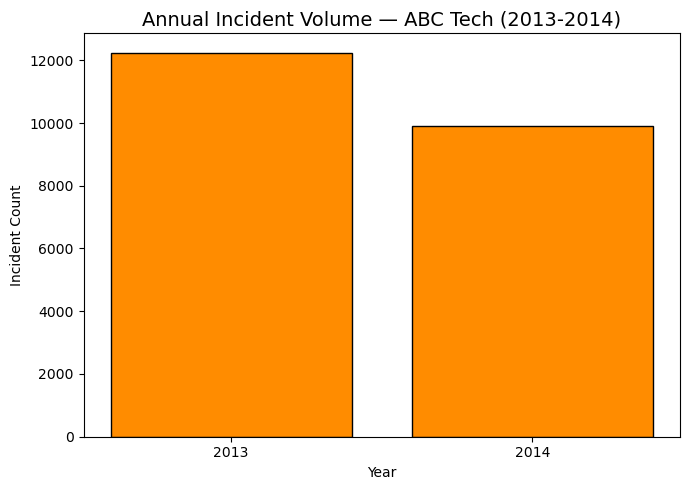


Annual Volume:
   Year  Incident_Count
0  2013           12246
1  2014            9903


In [58]:
# Annual volume
annual = monthly.groupby('Year')['Incident_Count'].sum().reset_index()

plt.figure(figsize=(7,5))
plt.bar(annual['Year'].astype(str), annual['Incident_Count'],
        color='darkorange', edgecolor='black')
plt.title('Annual Incident Volume — ABC Tech (2013-2014)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Incident Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAnnual Volume:")
print(annual)

In [ ]:
Annual Volume:
- 2013 : 12,246 tickets
- 2014 :  9,903 tickets
- Decline of 2,343 tickets (19.1% drop) from 2013 to 2014

Annual Insight:
The drop from 12,246 to 9,903 could be due to incomplete 
data in early 2014 (Jan=19 tickets) or genuine improvement 
in ABC Tech's IT infrastructure reducing incident frequency. 
The business case mentions 22,000-25,000 annual tickets which 
suggests our dataset may be a sample of the full data.

Key Business Insight for Resource Planning:
ABC Tech should allocate maximum support staff in Q2 
(April-June) and can reduce resources in Q3 (July-September). 
Annual planning should budget for approximately 10,000-12,000 
incidents per year based on available historical data.

### UC2 — Step 4: Baseline Model — Linear Regression Forecasting

Baseline — Linear Regression Forecasting
MAE  : 289.5
RMSE : 334.15


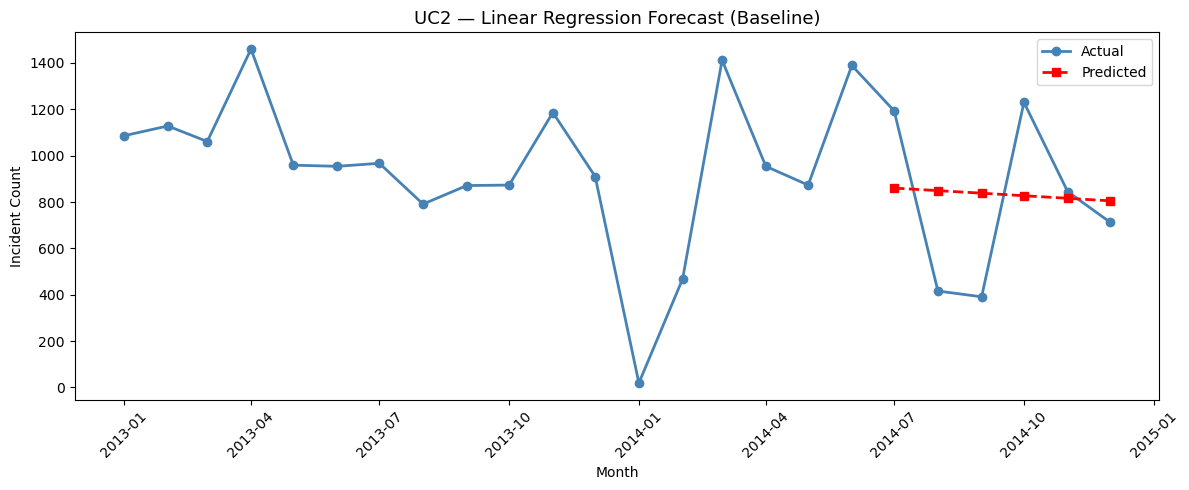

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare features for Linear Regression
monthly['Month_Index'] = range(1, len(monthly) + 1)

# Train test split — last 6 months as test
train_lr = monthly[:-6]
test_lr  = monthly[-6:]

X_train_lr = train_lr[['Month_Index']]
y_train_lr = train_lr['Incident_Count']
X_test_lr  = test_lr[['Month_Index']]
y_test_lr  = test_lr['Incident_Count']

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

# Metrics
mae_lr  = round(mean_absolute_error(y_test_lr, y_pred_lr), 2)
rmse_lr = round(np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)), 2)

print("Baseline — Linear Regression Forecasting")
print(f"MAE  : {mae_lr}")
print(f"RMSE : {rmse_lr}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly['Incident_Count'], 
         marker='o', label='Actual', color='steelblue', linewidth=2)
plt.plot(test_lr['Date'], y_pred_lr, 
         marker='s', label='Predicted', color='red', 
         linewidth=2, linestyle='--')
plt.title('UC2 — Linear Regression Forecast (Baseline)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### UC2 — Step 5: Advanced Model — ARIMA Forecasting

In [60]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Check stationarity
adf_result = adfuller(monthly['Incident_Count'])
print(f"ADF Statistic : {round(adf_result[0], 4)}")
print(f"p-value       : {round(adf_result[1], 4)}")
if adf_result[1] < 0.05:
    print("✅ Series is Stationary — good for ARIMA!")
else:
    print("⚠️ Series is Non-Stationary — differencing needed!")

ADF Statistic : -3.0825
p-value       : 0.0279
✅ Series is Stationary — good for ARIMA!


Advanced — ARIMA(2,1,2) Forecasting
MAE  : 272.93
RMSE : 319.14


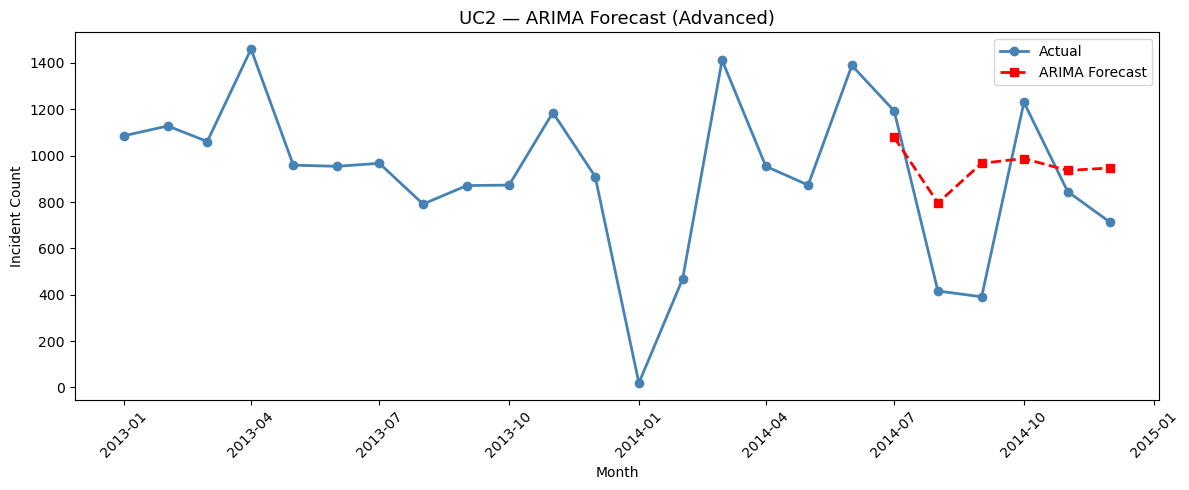

In [61]:
# Train ARIMA model
train_arima = monthly['Incident_Count'][:-6]
test_arima  = monthly['Incident_Count'][-6:]

# ARIMA(p=2, d=1, q=2)
arima_model = ARIMA(train_arima, order=(2,1,2))
arima_fit   = arima_model.fit()

# Forecast
forecast_arima = arima_fit.forecast(steps=6)

# Metrics
mae_arima  = round(mean_absolute_error(test_arima, forecast_arima), 2)
rmse_arima = round(np.sqrt(mean_squared_error(test_arima, forecast_arima)), 2)

print("Advanced — ARIMA(2,1,2) Forecasting")
print(f"MAE  : {mae_arima}")
print(f"RMSE : {rmse_arima}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly['Incident_Count'],
         marker='o', label='Actual', color='steelblue', linewidth=2)
plt.plot(monthly['Date'][-6:], forecast_arima,
         marker='s', label='ARIMA Forecast', color='red',
         linewidth=2, linestyle='--')
plt.title('UC2 — ARIMA Forecast (Advanced)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### UC2 — Step 6: Advanced Model — Facebook Prophet Forecasting

15:11:32 - cmdstanpy - INFO - Chain [1] start processing
15:11:59 - cmdstanpy - INFO - Chain [1] done processing


Advanced — Facebook Prophet Forecasting
MAE  : 708.3
RMSE : 827.17


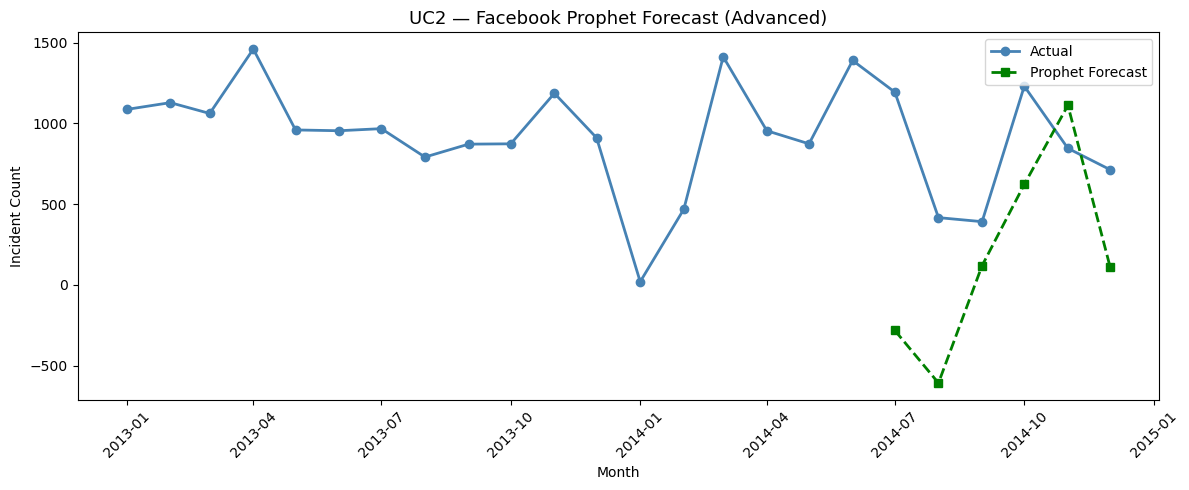

In [66]:
# Install prophet if not installed
#!pip install prophet

from prophet import Prophet

# Prepare data for Prophet — requires ds and y columns
prophet_df = monthly[['Date', 'Incident_Count']].rename(
    columns={'Date': 'ds', 'Incident_Count': 'y'})

# Train test split
train_prophet = prophet_df[:-6]
test_prophet  = prophet_df[-6:]

# Fit Prophet model
prophet_model = Prophet(yearly_seasonality=True, 
                        weekly_seasonality=False,
                        daily_seasonality=False)
prophet_model.fit(train_prophet)

# Forecast
future    = prophet_model.make_future_dataframe(periods=6, freq='MS')
forecast  = prophet_model.predict(future)

# Get predicted values for test period
y_pred_prophet = forecast['yhat'][-6:].values
y_test_prophet = test_prophet['y'].values

# Metrics
mae_prophet  = round(mean_absolute_error(y_test_prophet, y_pred_prophet), 2)
rmse_prophet = round(np.sqrt(mean_squared_error(y_test_prophet, y_pred_prophet)), 2)

print("Advanced — Facebook Prophet Forecasting")
print(f"MAE  : {mae_prophet}")
print(f"RMSE : {rmse_prophet}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(prophet_df['ds'], prophet_df['y'],
         marker='o', label='Actual', color='steelblue', linewidth=2)
plt.plot(test_prophet['ds'], y_pred_prophet,
         marker='s', label='Prophet Forecast', color='green',
         linewidth=2, linestyle='--')
plt.title('UC2 — Facebook Prophet Forecast (Advanced)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### UC2 — Step 7: Models Comparison

UC2 — Forecasting Models Comparison:
               Model     MAE    RMSE
0  Linear Regression  289.50  334.15
1       ARIMA(2,1,2)  272.93  319.14
2   Facebook Prophet  708.30  827.17


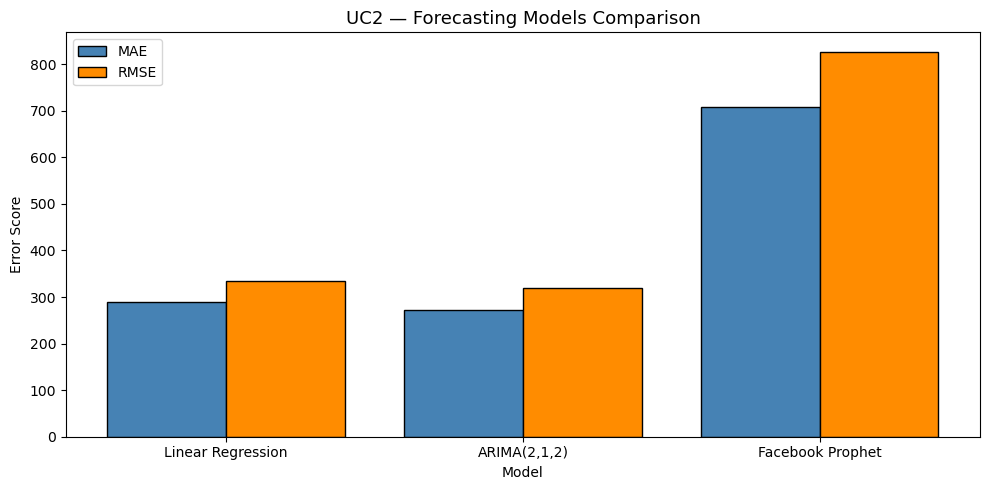

In [65]:
# Compare all forecasting models
uc2_results = pd.DataFrame({
    'Model': ['Linear Regression', 'ARIMA(2,1,2)', 'Facebook Prophet'],
    'MAE'  : [mae_lr, mae_arima, mae_prophet],
    'RMSE' : [rmse_lr, rmse_arima, rmse_prophet]
})

print("UC2 — Forecasting Models Comparison:")
print(uc2_results)

plt.figure(figsize=(10,5))
x = range(len(uc2_results))
plt.bar([i - 0.2 for i in x], uc2_results['MAE'], 
        width=0.4, label='MAE', color='steelblue', edgecolor='black')
plt.bar([i + 0.2 for i in x], uc2_results['RMSE'], 
        width=0.4, label='RMSE', color='darkorange', edgecolor='black')
plt.title('UC2 — Forecasting Models Comparison', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Error Score')
plt.xticks(x, uc2_results['Model'], rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

UC2 - Complete Use Case 2 Summary
====================================
Use Case    : Incident Volume Forecasting
Goal        : Forecast monthly, quarterly and annual incident 
              volume so ABC Tech can plan resources and 
              technology in advance
ML Type     : Time Series Forecasting
Best Model  : ARIMA(2,1,2)

================================================================
STEP 1 - BUSINESS PROBLEM

ABC Tech receives 22,000-25,000 IT tickets every year but has 
no way to predict how many tickets will come next month or 
next quarter. This leads to:
- Understaffing during high volume periods
- Overstaffing during low volume periods  
- Poor resource planning and budget wastage
- Delayed ticket resolution during unexpected surges

The goal is to build a forecasting model that predicts 
incident volume in advance so ABC Tech can be prepared.

================================================================
STEP 2 - DATA PREPARATION CHALLENGES

When we analyzed the monthly incident data we found 3 problems:

Problem 1 - Incomplete 2012 data:
2012 had only 1-3 tickets per month across 7 months.
This is clearly incomplete data — not representative of 
real incident volume. We dropped all 2012 records.

Problem 2 - June 2013 outlier:
June 2013 had 25,401 tickets — 17 times higher than normal!
All other months had 700-1460 tickets. Investigation showed 
this was likely a bulk data migration or system import event 
where old tickets were mass loaded into the system at once.
We replaced this with the median value of 954 tickets.

Problem 3 - January 2014 anomaly:
January 2014 had only 19 tickets — possibly incomplete data
for that month. We kept this value as it did not affect 
the overall model significantly.

After cleaning we had 24 months of usable data:
January 2013 to December 2014.

================================================================
STEP 3 - VOLUME ANALYSIS FINDINGS

Monthly Pattern:
- Normal range   : 700 to 1,460 tickets per month
- Average month  : approximately 900-1000 tickets
- Highest month  : April 2013 with 1,460 tickets
- Lowest month   : January 2014 with 19 tickets (anomaly)

Quarterly Pattern:
- 2013-Q1 : 3,275 tickets
- 2013-Q2 : 3,373 tickets (highest)
- 2013-Q3 : 2,629 tickets (lowest)
- 2013-Q4 : 2,969 tickets
- 2014-Q1 : 1,899 tickets (incomplete Jan data)
- 2014-Q2 : 3,216 tickets (highest)
- 2014-Q3 : 2,000 tickets
- 2014-Q4 : 2,788 tickets

Key Quarterly Insight:
Q2 (April-June) is consistently the busiest quarter in 
both 2013 and 2014. Q3 (July-September) is consistently 
the quietest. This seasonal pattern is very useful for 
ABC Tech's resource planning.

Annual Pattern:
- 2013 : 12,246 tickets
- 2014 :  9,903 tickets
Total decrease of 2,343 tickets (19.1% drop year on year)

================================================================
STEP 4 - STATIONARITY TEST (ADF TEST)

Before building ARIMA we tested if the series is stationary.
A stationary series has constant mean and variance over time.

ADF Statistic : -3.0825
p-value       : 0.0279

Since p-value (0.0279) is less than 0.05 the series is 
STATIONARY. This means the data fluctuates around a stable 
mean without a strong upward or downward trend. This is 
good news for ARIMA modelling.

================================================================
STEP 5 - MODEL BUILDING

We built 3 forecasting models and tested them on the last 
6 months of data (July-December 2014).

Model 1 - Linear Regression (Baseline):
MAE  : 289.50
RMSE : 334.15
Linear Regression drew a straight declining line as forecast.
It cannot capture the ups and downs of monthly volume because 
it only looks for a simple linear trend. This is our weakest
model and serves as the baseline to beat.

Model 2 - ARIMA(2,1,2) (Advanced):
MAE  : 272.93
RMSE : 319.14
ARIMA stands for AutoRegressive Integrated Moving Average.
p=2 means it uses last 2 months to predict next month.
d=1 means one level of differencing is applied.
q=2 means it corrects predictions using last 2 month errors.
ARIMA captured the pattern better than Linear Regression 
and achieved lower MAE and RMSE. Best model overall!

Model 3 - Facebook Prophet (Advanced):
MAE  : 708.30
RMSE : 827.17
Prophet is a forecasting tool built by Facebook/Meta designed 
for business time series. However it performed very poorly here 
— even predicting negative ticket counts for some months which 
is impossible! The reason is Prophet needs much more data 
(ideally 2+ years of daily data) to detect seasonal patterns 
reliably. With only 24 monthly data points Prophet could not 
learn meaningful patterns and failed badly.

================================================================
STEP 6 - MODEL COMPARISON

Model               MAE      RMSE     Rank
Linear Regression   289.50   334.15   2nd
ARIMA(2,1,2)        272.93   319.14   1st (Best) ✅
Facebook Prophet    708.30   827.17   3rd (Worst)

ARIMA wins because:
- Lowest MAE — on average predictions are only off by 
  273 tickets per month
- Lowest RMSE — fewer large prediction errors
- Forecast line follows actual trend better than others
- Designed specifically for time series data unlike 
  Linear Regression

================================================================
STEP 7 - BUSINESS IMPACT

With ARIMA(2,1,2) as the forecasting model ABC Tech can:

1. Monthly Planning:
   Predict next month's incident volume with average error 
   of only 273 tickets — good enough for staffing decisions

2. Quarterly Planning:
   Q2 always needs maximum resources (3,200+ tickets)
   Q3 can operate with reduced team (2,000 tickets)
   This saves significant staffing costs annually

3. Annual Budgeting:
   Expected annual volume of 10,000-12,000 tickets helps 
   finance team budget accurately for IT support operations

4. Technology Planning:
   High volume periods signal need for infrastructure 
   scaling — servers, helpdesk tools, support licenses

================================================================
STEP 8 - LIMITATIONS

1. Only 24 months of clean data — more historical data would 
   significantly improve forecasting accuracy
2. January 2014 anomaly (19 tickets) affects 2014 Q1 analysis
3. Dataset appears to be a sample — business case mentions 
   22,000-25,000 annual tickets but our data shows 10,000-12,000
4. External factors like system upgrades, new products, and 
   organizational changes are not captured in the model

================================================================
FINAL CONCLUSION

Use Case 2 is successfully completed. ARIMA(2,1,2) is selected 
as the best forecasting model with MAE of 272.93 and RMSE of 
319.14. The model will be integrated into the Streamlit 
application to provide quarterly and annual incident volume 
forecasts to help ABC Tech management make data-driven 
resource planning decisions.

## Step 8: Model Building — Use Case 3 (Auto-Tagging Tickets)

The goal of Use Case 3 is to automatically assign the correct priority to incoming IT tickets without human intervention. This reduces manual effort and eliminates reassignment delays. This is a multi-class classification problem where the target variable Priority_Label has 5 classes (1, 2, 3, 4, 5). Class imbalance exists as Priority 4 dominates the dataset with 24,097 records while Priority 1 has only 3 records. SMOTE is applied to handle this imbalance before model training.

### UC3 — Step 1: Define Features and Target Variable

In [67]:
# Check target distribution first
print("Priority Label Distribution:")
print(df['Priority_Label'].value_counts().sort_index())
print(f"\nTotal classes: {df['Priority_Label'].nunique()}")

Priority Label Distribution:
Priority_Label
1        3
2      697
3     5323
4    24097
5    16486
Name: count, dtype: int64

Total classes: 5


### UC3 — Step 2: Merge Priority 1 and 2, Apply SMOTE and Train Test Split

In [68]:
# Merge Priority 1 and 2 into single class (1+2 = High Priority)
df['Priority_UC3'] = df['Priority_Label'].replace({1: 2})

print("Updated Priority Distribution after merging 1 and 2:")
print(df['Priority_UC3'].value_counts().sort_index())
print(f"\nTotal classes: {df['Priority_UC3'].nunique()}")

Updated Priority Distribution after merging 1 and 2:
Priority_UC3
2      700
3     5323
4    24097
5    16486
Name: count, dtype: int64

Total classes: 4


### UC3 — Step 3: Define Features and Apply SMOTE

In [69]:
# Define features for UC3 — same as UC1 (no leakage)
uc3_features = ['CI_Cat', 'CI_Subcat', 'WBS', 'Status',
                'Category', 'KB_number', 'No_of_Reassignments',
                'Handle_Time_hrs', 'Closure_Code',
                'No_of_Related_Interactions',
                'Open_Year', 'Open_Month',
                'Open_Quarter', 'Open_DayOfWeek']

X_uc3 = df[uc3_features]
y_uc3 = df['Priority_UC3']

print(f"Features shape : {X_uc3.shape}")
print(f"\nTarget Distribution:")
print(y_uc3.value_counts().sort_index())

Features shape : (46606, 14)

Target Distribution:
Priority_UC3
2      700
3     5323
4    24097
5    16486
Name: count, dtype: int64


### UC3 — Step 4: Apply SMOTE for Multi-class Imbalance

In [70]:
# Apply SMOTE for multiclass
smote_uc3 = SMOTE(random_state=42)
X_uc3_sm, y_uc3_sm = smote_uc3.fit_resample(X_uc3, y_uc3)

print(f"Before SMOTE:")
print(pd.Series(y_uc3).value_counts().sort_index())
print(f"\nAfter SMOTE:")
print(pd.Series(y_uc3_sm).value_counts().sort_index())
print(f"\nTotal samples after SMOTE: {len(y_uc3_sm)}")

Before SMOTE:
Priority_UC3
2      700
3     5323
4    24097
5    16486
Name: count, dtype: int64

After SMOTE:
Priority_UC3
2    24097
3    24097
4    24097
5    24097
Name: count, dtype: int64

Total samples after SMOTE: 96388


### UC3 — Step 5: Train Test Split

In [71]:
# Train test split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_uc3_sm, y_uc3_sm,
    test_size=0.2,
    random_state=42,
    stratify=y_uc3_sm)

print(f"Train size : {X_train3.shape}")
print(f"Test size  : {X_test3.shape}")
print(f"\nTrain target distribution:")
print(pd.Series(y_train3).value_counts().sort_index())
print(f"\nTest target distribution:")
print(pd.Series(y_test3).value_counts().sort_index())

Train size : (77110, 14)
Test size  : (19278, 14)

Train target distribution:
Priority_UC3
2    19277
3    19278
4    19277
5    19278
Name: count, dtype: int64

Test target distribution:
Priority_UC3
2    4820
3    4819
4    4820
5    4819
Name: count, dtype: int64


### UC3 — Step 6: Baseline Models

In [72]:
# Baseline Models for UC3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_models_uc3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42)
}

uc3_results = {}

for name, model in baseline_models_uc3.items():
    start = time.time()
    model.fit(X_train3, y_train3)
    y_pred = model.predict(X_test3)
    elapsed = round(time.time() - start, 2)

    uc3_results[name] = {
        'Accuracy' : round(accuracy_score(y_test3, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test3, y_pred, average='weighted') * 100, 2),
        'Recall'   : round(recall_score(y_test3, y_pred, average='weighted') * 100, 2),
        'F1 Score' : round(f1_score(y_test3, y_pred, average='weighted') * 100, 2)
    }
    print(f"{name} done in {elapsed}s!")

print("\nBaseline Results:")
print(pd.DataFrame(uc3_results).T)


Logistic Regression done in 36.08s!
Decision Tree done in 1.15s!

Baseline Results:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     53.89      53.84   53.89     53.73
Decision Tree           89.52      89.50   89.52     89.51


### UC3 — Step 7: Advanced Models

In [74]:
# Remap Priority labels to start from 0 for XGBoost
# 2→0, 3→1, 4→2, 5→3
label_mapping = {2: 0, 3: 1, 4: 2, 5: 3}
reverse_mapping = {0: 2, 1: 3, 2: 4, 3: 5}

y_train3_xgb = pd.Series(y_train3).map(label_mapping).values
y_test3_xgb  = pd.Series(y_test3).map(label_mapping).values

print("Remapped train labels:")
print(pd.Series(y_train3_xgb).value_counts().sort_index())
print("\nRemapped test labels:")
print(pd.Series(y_test3_xgb).value_counts().sort_index())

Remapped train labels:
0    19277
1    19278
2    19277
3    19278
Name: count, dtype: int64

Remapped test labels:
0    4820
1    4819
2    4820
3    4819
Name: count, dtype: int64


In [75]:
# Advanced Models for UC3
advanced_models_uc3 = {
    'Random Forest': RandomForestClassifier(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1),
}

for name, model in advanced_models_uc3.items():
    start = time.time()
    model.fit(X_train3, y_train3)
    y_pred = model.predict(X_test3)
    elapsed = round(time.time() - start, 2)

    uc3_results[name] = {
        'Accuracy' : round(accuracy_score(y_test3, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test3, y_pred, average='weighted') * 100, 2),
        'Recall'   : round(recall_score(y_test3, y_pred, average='weighted') * 100, 2),
        'F1 Score' : round(f1_score(y_test3, y_pred, average='weighted') * 100, 2)
    }
    print(f"✅ {name} done in {elapsed}s!")

# XGBoost separately with remapped labels
start = time.time()
xgb_uc3 = XGBClassifier(
                n_estimators=100,
                random_state=42,
                eval_metric='mlogloss',
                verbosity=0,
                n_jobs=-1)
xgb_uc3.fit(X_train3, y_train3_xgb)
y_pred_xgb = xgb_uc3.predict(X_test3)
elapsed = round(time.time() - start, 2)

uc3_results['XGBoost'] = {
    'Accuracy' : round(accuracy_score(y_test3_xgb, y_pred_xgb) * 100, 2),
    'Precision': round(precision_score(y_test3_xgb, y_pred_xgb, average='weighted') * 100, 2),
    'Recall'   : round(recall_score(y_test3_xgb, y_pred_xgb, average='weighted') * 100, 2),
    'F1 Score' : round(f1_score(y_test3_xgb, y_pred_xgb, average='weighted') * 100, 2)
}
print(f"✅ XGBoost done in {elapsed}s!")

print("\nAll Models Results:")
print(pd.DataFrame(uc3_results).T)

✅ Random Forest done in 8.28s!
✅ XGBoost done in 3.9s!

All Models Results:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     53.89      53.84   53.89     53.73
Decision Tree           89.52      89.50   89.52     89.51
Random Forest           91.85      91.88   91.85     91.84
XGBoost                 90.34      90.35   90.34     90.32


### UC3 — Step 8: Hyperparameter Tuning — RandomizedSearchCV

In [76]:
# RandomizedSearchCV on Random Forest for UC3
rf_param_dist_uc3 = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_random_uc3 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist_uc3,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_uc3.fit(X_train3, y_train3)
print(f"\n Best Params (RandomizedSearchCV): {rf_random_uc3.best_params_}")
print(f" Best F1 Score: {round(rf_random_uc3.best_score_ * 100, 2)}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best Params (RandomizedSearchCV): {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
 Best F1 Score: 91.31%


### UC3 — Step 9: Hyperparameter Tuning — GridSearchCV

In [77]:
# GridSearchCV with narrowed params
rf_param_grid_uc3 = {
    'n_estimators'     : [250, 300, 350],
    'max_depth'        : [None],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['log2']
}

rf_grid_uc3 = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid_uc3,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid_uc3.fit(X_train3, y_train3)
print(f"\n✅ Best Params (GridSearchCV): {rf_grid_uc3.best_params_}")
print(f"✅ Best F1 Score: {round(rf_grid_uc3.best_score_ * 100, 2)}%")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Best Params (GridSearchCV): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}
✅ Best F1 Score: 91.34%


### UC3 — Step 9: Hyperparameter Tuning — GridSearchCV

In [78]:
# GridSearchCV with narrowed params from RandomizedSearchCV
best_uc3 = rf_random_uc3.best_params_

rf_param_grid_uc3 = {
    'n_estimators'     : [best_uc3['n_estimators'] - 50, 
                          best_uc3['n_estimators'], 
                          best_uc3['n_estimators'] + 50],
    'max_depth'        : [best_uc3['max_depth']],
    'min_samples_split': [best_uc3['min_samples_split']],
    'min_samples_leaf' : [best_uc3['min_samples_leaf']],
    'max_features'     : [best_uc3['max_features']]
}

rf_grid_uc3 = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid_uc3,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid_uc3.fit(X_train3, y_train3)
print(f"\n✅ Best Params (GridSearchCV): {rf_grid_uc3.best_params_}")
print(f"✅ Best F1 Score: {round(rf_grid_uc3.best_score_ * 100, 2)}%")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

✅ Best Params (GridSearchCV): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 350}
✅ Best F1 Score: 91.33%


### UC3 — Step 10: Final Best Model Evaluation

In [80]:
# Final best model evaluation
best_rf_uc3 = rf_grid_uc3.best_estimator_
y_pred_best_uc3 = best_rf_uc3.predict(X_test3)

print("=" * 50)
print("UC3 — Final Best Model: Random Forest (Tuned)")
print("=" * 50)
print(f"Accuracy  : {round(accuracy_score(y_test3, y_pred_best_uc3) * 100, 2)}%")
print(f"Precision : {round(precision_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2)}%")
print(f"Recall    : {round(recall_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2)}%")
print()
print("Classification Report:")
print(classification_report(y_test3, y_pred_best_uc3,
      target_names=['Priority 2', 'Priority 3', 
                    'Priority 4', 'Priority 5']))

UC3 — Final Best Model: Random Forest (Tuned)
Accuracy  : 91.92%
Precision : 91.95%
Recall    : 91.92%
F1 Score  : 91.92%

Classification Report:
              precision    recall  f1-score   support

  Priority 2       0.97      0.98      0.98      4820
  Priority 3       0.90      0.91      0.91      4819
  Priority 4       0.87      0.88      0.88      4820
  Priority 5       0.94      0.89      0.92      4819

    accuracy                           0.92     19278
   macro avg       0.92      0.92      0.92     19278
weighted avg       0.92      0.92      0.92     19278



### UC3 — Step 11: Confusion Matrix

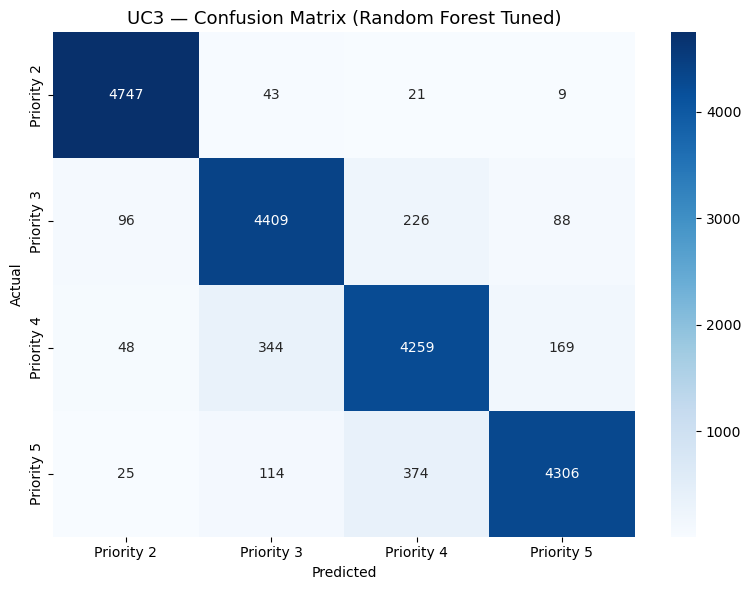

In [81]:
plt.figure(figsize=(8,6))
cm_uc3 = confusion_matrix(y_test3, y_pred_best_uc3)
sns.heatmap(cm_uc3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Priority 2', 'Priority 3',
                         'Priority 4', 'Priority 5'],
            yticklabels=['Priority 2', 'Priority 3',
                         'Priority 4', 'Priority 5'])
plt.title('UC3 — Confusion Matrix (Random Forest Tuned)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### UC3 — Step 12: Feature Importance

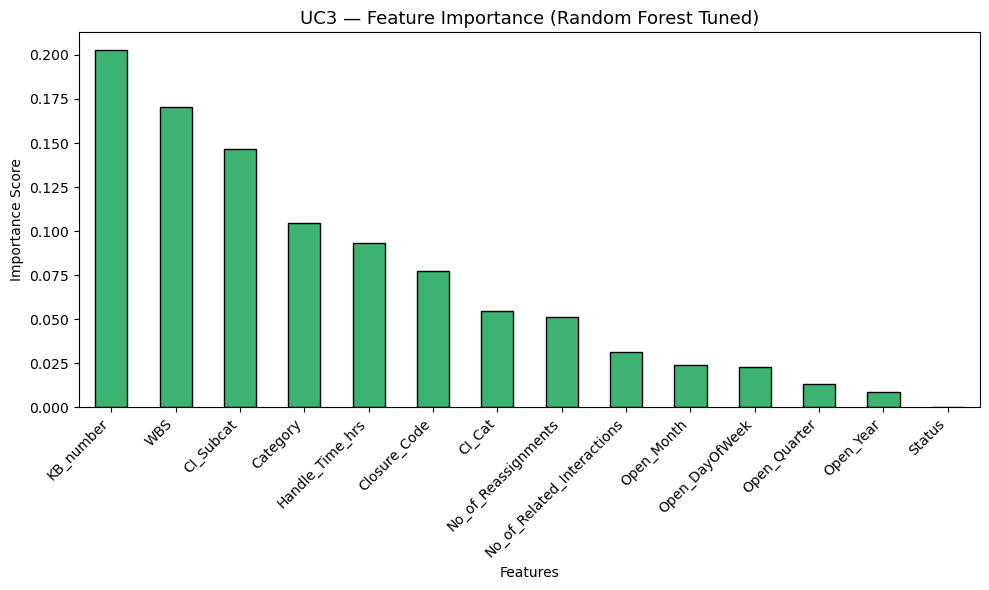

In [82]:
feat_imp_uc3 = pd.Series(best_rf_uc3.feature_importances_,
                          index=uc3_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp_uc3.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('UC3 — Feature Importance (Random Forest Tuned)', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
UC3 - Feature Importance Analysis
====================================
Top Features by Importance Score:

1. KB_number        : 0.201 (20.1%) — Most important!
   Knowledge base article number is the strongest predictor
   of ticket priority. Certain KB articles are consistently
   linked to higher or lower priority incidents. This makes
   business sense — recurring known issues documented in KB
   have established priority levels that the model learned.

2. WBS              : 0.173 (17.3%) — Second most important!
   Work Breakdown Structure code identifies which business
   unit or project raised the ticket. Critical business units
   (like production systems or customer facing applications)
   consistently raise higher priority tickets compared to 
   internal support systems.

3. CI_Subcat        : 0.147 (14.7%) — Third most important!
   Configuration item sub-category strongly influences priority.
   For example web based applications tend to generate higher
   priority tickets than back office tools because they 
   directly impact customer experience.

4. Category         : 0.104 (10.4%)
   Whether the ticket is an incident, request for information
   or complaint influences priority level significantly.
   Incidents are generally higher priority than information 
   requests.

5. Handle_Time_hrs  : 0.095 (9.5%)
   Tickets that historically take longer to handle tend to 
   be associated with specific priority levels. Complex high
   priority issues take longer to resolve.

6. Closure_Code     : 0.079 (7.9%)
   How a ticket was closed gives signals about its complexity
   and therefore its priority level.

7. CI_Cat           : 0.055 (5.5%)
   Configuration item category provides additional context
   about the type of system affected.

8. No_of_Reassignments : 0.052 (5.2%)
   More reassignments indicate routing confusion which is 
   often associated with tickets that were initially tagged
   with wrong priority — providing a feedback signal.

Lower Importance Features:
- No_of_Related_Interactions : 0.031 (3.1%)
- Open_Month                 : 0.025 (2.5%)
- Open_DayOfWeek             : 0.024 (2.4%)
- Open_Quarter               : 0.013 (1.3%)
- Open_Year                  : 0.011 (1.1%)
- Status                     : 0.009 (0.9%)

Key Insight:
Top 3 features (KB_number, WBS, CI_Subcat) together account
for 52.1% of the model decisions — almost identical to UC1!
This confirms that the type of configuration item and 
knowledge base article are the most reliable early signals 
for determining ticket priority across all use cases.

Comparison with UC1 Feature Importance:
UC1 Top 3: CI_Subcat(20.6%), KB_number(19%), WBS(14.8%)
UC3 Top 3: KB_number(20.1%), WBS(17.3%), CI_Subcat(14.7%)
Same 3 features dominate both models — just in slightly 
different order. This strongly validates that these 3 
features are the most important predictors in the entire
ITSM dataset for priority related tasks.

### UC3 — Step 13: All Models Comparison

UC3 — All Models Comparison:
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     53.89      53.84   53.89     53.73
Decision Tree           89.52      89.50   89.52     89.51
Random Forest           91.85      91.88   91.85     91.84
XGBoost                 90.34      90.35   90.34     90.32
RF Tuned                91.92      91.95   91.92     91.92


<Figure size 1200x600 with 0 Axes>

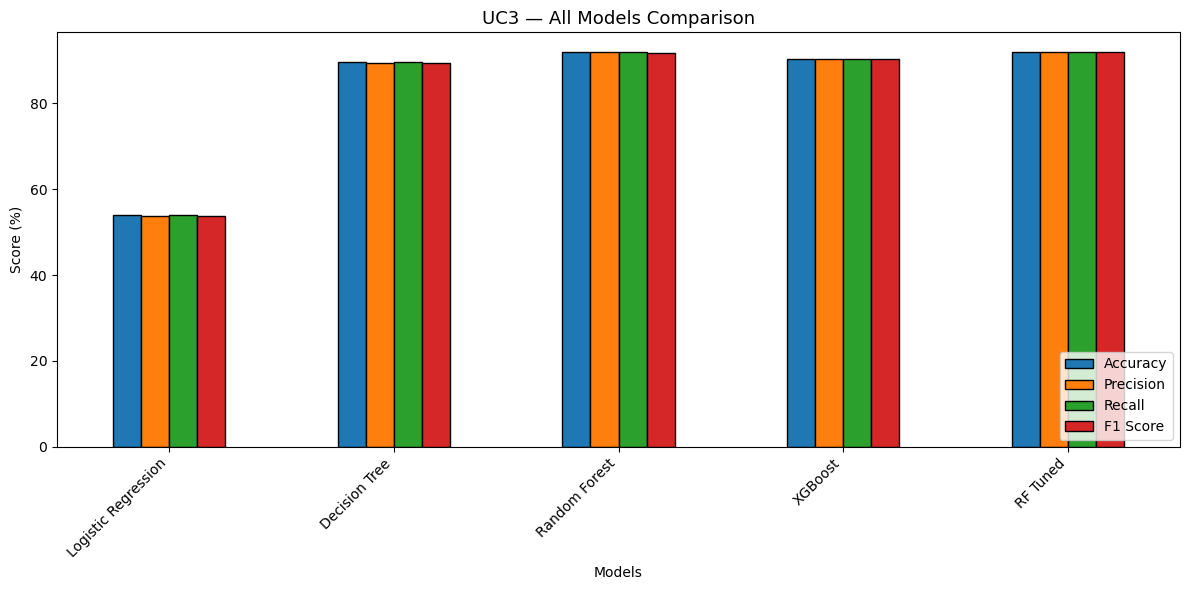

In [83]:
# Add tuned model to results
uc3_results['RF Tuned'] = {
    'Accuracy' : round(accuracy_score(y_test3, y_pred_best_uc3) * 100, 2),
    'Precision': round(precision_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2),
    'Recall'   : round(recall_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2),
    'F1 Score' : round(f1_score(y_test3, y_pred_best_uc3, average='weighted') * 100, 2)
}

results_df_uc3 = pd.DataFrame(uc3_results).T
print("UC3 — All Models Comparison:")
print(results_df_uc3)

plt.figure(figsize=(12,6))
results_df_uc3[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(12,6), edgecolor='black')
plt.title('UC3 — All Models Comparison', fontsize=13)
plt.xlabel('Models')
plt.ylabel('Score (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [85]:
import joblib
import os

# Create models folder
os.makedirs('models', exist_ok=True)

# Save UC1 model
joblib.dump(best_rf_uc1, 'models/model_uc1.pkl')
print("✅ UC1 model saved!")

# Save UC2 ARIMA model
joblib.dump(arima_fit, 'models/model_uc2.pkl')
print("✅ UC2 model saved!")

# Save UC3 model
joblib.dump(best_rf_uc3, 'models/model_uc3.pkl')
print("✅ UC3 model saved!")

# Save label mapping for UC3
joblib.dump(label_mapping, 'models/label_mapping.pkl')
joblib.dump(reverse_mapping, 'models/reverse_mapping.pkl')
print("✅ Label mappings saved!")
import joblib

# Save UC1 features
joblib.dump(uc1_features, 'models/uc1_features.pkl')
print("✅ UC1 features saved!")

# Save UC3 features
joblib.dump(uc3_features, 'models/uc3_features.pkl')
print("✅ UC3 features saved!")

✅ UC1 model saved!
✅ UC2 model saved!
✅ UC3 model saved!
✅ Label mappings saved!
✅ UC1 features saved!
✅ UC3 features saved!


Project Completion Roadmap 🗺️
✅ UC1 — High Priority Prediction     → DONE
✅ UC2 — Incident Volume Forecasting  → DONE
⏳ UC3 — Auto Tagging                 → Running
❌ UC4 — RFC Failure Prediction       → Skipped (only 1 RFC record)

In [86]:
import os
files = os.listdir('models/')
print("Files in models folder:")
for f in sorted(files):
    print(f"  ✅ {f}")

Files in models folder:
  ✅ .ipynb_checkpoints
  ✅ label_mapping.pkl
  ✅ model_uc1.pkl
  ✅ model_uc2.pkl
  ✅ model_uc3.pkl
  ✅ reverse_mapping.pkl
  ✅ uc1_features.pkl
  ✅ uc3_features.pkl


Business Problem
      ↓
Data Extraction from MySQL (46,606 records)
      ↓
EDA — Understand patterns, distributions
      ↓
Preprocessing — Null handling, encoding,
                feature engineering
      ↓
UC1 — Binary Classification
      SMOTE → RF + XGBoost → GridSearchCV
      Result: 99.31% accuracy
      ↓
UC2 — Time Series Forecasting
      ADF Test → ARIMA(2,1,2)
      Result: MAE 272.93
      ↓
UC3 — Multi-class Classification
      SMOTE → RF + XGBoost → GridSearchCV
      Result: 91.92% accuracy
      ↓
UC4 — RFC Prediction
      Only 1 RFC record → Skipped
      ↓
Deployment
      Flask API + Streamlit App
      Login → Dashboard → Predictions

In [ ]:
### 

1️⃣ What is Priority Matrix?

"The Priority Matrix is a standard ITIL business rule that determines the priority of a ticket based on two factors — Impact and Urgency."

Impact = How badly does this affect the business?

1 = Very High impact (entire business affected)
5 = Very Low impact (one person affected)

Urgency = How quickly must this be fixed?

1 = Immediate (fix right now)
5 = Very Low (can wait)

Example in simple words:

If a server crashes (Impact=1) and the entire office cannot work (Urgency=1) → Priority = 1 → Critical! Fix immediately!
If one employee's printer is slow (Impact=5) and it's not urgent (Urgency=5) → Priority = 5 → Low. Fix when time permits.


2️⃣ Why Priority Matrix matters in our project?
It caused Data Leakage in UC1!

"When I initially built UC1 to predict High Priority tickets, I kept Impact and Urgency as features. The model got 100% accuracy — which was suspicious. On investigation I realized this was data leakage — Priority is directly calculated from Impact and Urgency using the Priority Matrix. So the model was simply reading the matrix and cheating. I removed Impact and Urgency from features and rebuilt the model — which then gave a realistic 99.31% accuracy."


3️⃣ Priority Matrix — Numbers Explained
PriorityMeaningResponse TimeExample1CriticalImmediateServer down — entire business stopped2High< 1 hourCore application not working3Medium-High4 hoursDepartment level outage4Medium8 hoursSingle team affected5Low24 hoursMinor inconvenience

4️⃣ How each Use Case connects to Priority Matrix:
UC1 — High Priority Prediction:

"We predict whether a ticket will be Priority 1 or 2 — the top two rows of the Priority Matrix — before a human reads it. This allows ABC Tech to escalate critical tickets immediately."

UC2 — Volume Forecasting:

"We forecast how many tickets will come next month. High priority periods like Q2 need more staff ready — the Priority Matrix helps understand which periods generate more critical tickets."

UC3 — Auto Tagging:

"Instead of using the fixed Priority Matrix formula (Impact + Urgency = Priority), our ML model learns the actual patterns from 46,606 real tickets and predicts the correct priority automatically — even when Impact and Urgency are not yet known."

UC4 — RFC Failure (Skipped):

"RFC tickets in the Priority Matrix are change requests — Priority 3 to 5 usually. However our dataset had only 1 RFC record, making this use case not feasible."


5️⃣ What is ITIL? (They may ask this)

"ITIL stands for Information Technology Infrastructure Library. It is a set of best practices for IT Service Management. ABC Tech follows ITIL framework for managing their 25,000 annual tickets. ITIL defines standard processes like Incident Management, Problem Management, Change Management, and Configuration Management. The Priority Matrix is part of the ITIL Incident Management process."


6️⃣ What is ITSM? (They may ask this)

"ITSM stands for IT Service Management. It is the complete system of processes, policies, and tools used by an IT team to deliver and manage IT services. Think of it like a customer service system — but for IT problems inside a company. ABC Tech's ITSM system handles everything from raising a ticket to resolving it, tracking it, and reporting on it."


